In [2]:
!pip install xarray zarr gcsfs fsspec dask cftime intake intake-esm matplotlib seaborn intake



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.4/276.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.7/134.7 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 75.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 93.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.0/80.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.4/115.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.2 MB/s

In [3]:
# Mount + config (same folder you used before)
from google.colab import drive
from pathlib import Path
drive.mount("/content/drive", force_remount=True)
OUTDIR = Path("/content/drive/MyDrive/cmip/indices_day_filtered_ssp_hist")
OUTDIR.mkdir(parents=True, exist_ok=True)
print("Saving to:", OUTDIR)

Mounted at /content/drive
Saving to: /content/drive/MyDrive/cmip/indices_day_filtered_ssp_hist


In [ ]:


import intake, pandas as pd, numpy as np, xarray as xr
from tqdm.auto import tqdm

# decode-times helper
try:
    from xarray.coding.cftimeindex import CFDatetimeCoder
    _DECODE_TIMES_KW = dict(decode_times=CFDatetimeCoder(use_cftime=True))
except Exception:
    _DECODE_TIMES_KW = dict(use_cftime=True)

STORAGE_OPTS = {"token": "anon"}
PREF = ["r1i1p1f1","r1i1p1f2","r1i1p1f3","r1i1p1f4"]
MAX_YEARS_ABR = 150
DO_ABRUPT = True
STRICT_LAND = True  # set True to require sftlf; raises if missing

# --- your table models
TABLE_MODELS = [
    "ACCESS-CM2","ACCESS-ESM1-5","AWI-CM-1-1-MR","CAMS-CSM1-0","CMCC-CM2-SR5","CMCC-ESM2",
    "CNRM-CM6-1","CNRM-CM6-1-HR","CNRM-ESM2-1","CanESM5","EC-Earth3","EC-Earth3-CC",
    "EC-Earth3-Veg","EC-Earth3-Veg-LR","GFDL-CM4","GFDL-ESM4","HadGEM3-GC31-LL","IITM-ESM",
    "INM-CM4-8","INM-CM5-0","IPSL-CM6A-LR","NorESM2-LM","NorESM2-MM","TaiESM1",
    "UKESM1-0-LL"
]

# --- catalog + lookups (day only)
cat = intake.open_esm_datastore("https://storage.googleapis.com/cmip6/pangeo-cmip6.json")
df = cat.df

def _best_one(dfi):
    if dfi.empty: return None
    g = dfi.copy()
    g["pref_rank"] = g["member_id"].apply(lambda m: PREF.index(m) if m in PREF else 999)
    return g.sort_values(["pref_rank","version"], ascending=[True, False]).iloc[0]

def lookup_day(var, exp):
    d = df[(df.variable_id==var)&(df.table_id=="day")&(df.experiment_id==exp)&(df.source_id.isin(TABLE_MODELS))].copy()
    out={}
    for m,sub in d.groupby("source_id"):
        r=_best_one(sub)
        if r is not None:
            out[m]=dict(zstore=r.zstore, model=m, grid=r.grid_label, exp=exp)
    return out

def lookup_fx_sftlf():
    dfx=df[(df.variable_id=="sftlf")&(df.table_id=="fx")].copy(); L={}
    for (m,g),sub in dfx.groupby(["source_id","grid_label"]):
        r=_best_one(sub)
        if r is not None: L[(m,g)]=dict(zstore=r.zstore)
    return L

tas_hist, tas_ssp = lookup_day("tas","historical"), lookup_day("tas","ssp245")
tasmax_hist, tasmax_ssp = lookup_day("tasmax","historical"), lookup_day("tasmax","ssp245")
fx_lookup = lookup_fx_sftlf()
tas_abrt = lookup_day("tas","abrupt-4xCO2") if DO_ABRUPT else {}
tasmax_abrt = lookup_day("tasmax","abrupt-4xCO2") if DO_ABRUPT else {}

# require presence in BOTH historical & ssp245 (var-by-var)
models_tas    = sorted(set(tas_hist)&set(tas_ssp))
models_tasmax = sorted(set(tasmax_hist)&set(tasmax_ssp))
abrupt_tas    = sorted(set(models_tas)&set(tas_abrt)) if DO_ABRUPT else []
abrupt_tasmax = sorted(set(models_tasmax)&set(tasmax_abrt)) if DO_ABRUPT else []

print("Eligible tas:", len(models_tas))
print("Eligible tasmax:", len(models_tasmax))

# --- open / land / weights
def open_zarr(zurl):
    try:
        return xr.open_zarr(zurl, consolidated=True, storage_options=STORAGE_OPTS, **_DECODE_TIMES_KW)
    except Exception:
        return xr.open_zarr(zurl, consolidated=False, storage_options=STORAGE_OPTS, **_DECODE_TIMES_KW)

def land_mask(model, grid):
    key=(model,grid)
    if key in fx_lookup:
        ds=open_zarr(fx_lookup[key]["zstore"])
        if "sftlf" in ds:
            m=ds["sftlf"]
            if "time" in m.dims: m=m.isel(time=0)
            return (m>50)
    return None

def _broadcast_land_mask(da, model, grid):
    lm = land_mask(model, grid)
    if lm is None:
        if STRICT_LAND:
            raise RuntimeError(f"No sftlf land mask for {model}[{grid}]")
        return None
    return lm.broadcast_like(da.isel(time=0, drop=True))

def global_weighted(da):
    w=np.cos(np.deg2rad(da["lat"]))
    return da.weighted(w).mean(("lat","lon"), skipna=True)

# --- CORRECT definitions (LAND-MASKED for TDM/TDX):
# TDM = annual max of the daily spatial max of tas (land-only)
def TDM_max_anywhere_tas_day(meta):
    ds  = open_zarr(meta["zstore"])
    tas = ds["tas"].chunk({"time":60})
    lm  = _broadcast_land_mask(tas, meta["model"], meta.get("grid",""))
    if lm is not None:
        tas = tas.where(lm)
    daily_spatial_max = tas.max(("lat","lon"), skipna=True)
    return daily_spatial_max.groupby("time.year").max("time", skipna=True)

# TDX = annual max of the daily spatial max of tasmax (land-only)
def TDX_max_anywhere_tasmax_day(meta):
    ds  = open_zarr(meta["zstore"])
    tmx = ds["tasmax"].chunk({"time":60})
    lm  = _broadcast_land_mask(tmx, meta["model"], meta.get("grid",""))
    if lm is not None:
        tmx = tmx.where(lm)
    daily_spatial_max = tmx.max(("lat","lon"), skipna=True)
    return daily_spatial_max.groupby("time.year").max("time", skipna=True)

# TTL = tropical land (45S–45N) annual mean (land-only)
def TTL_tropical_land_tas_day(meta):
    ds  = open_zarr(meta["zstore"])
    tas = ds["tas"].sel(lat=slice(-45,45)).chunk({"time":60})
    lm  = land_mask(meta["model"], meta.get("grid",""))
    if lm is not None:
        lm = lm.sel(lat=slice(-45,45)).broadcast_like(tas.isel(time=0, drop=True))
        tas = tas.where(lm)
    gm = global_weighted(tas)
    return gm.groupby("time.year").mean("time", skipna=True)

def save_da(da, path, trim=None):
    if trim is not None:
        da = da.isel(year=slice(0,trim))
    np.save(path, da.compute().values)  # np.save overwrites existing files

# ---- SSP245 recompute (overwrite existing files)
print("\nRecomputing SSP245 (spatial MAX for TDM/TDX)…")
saved={"TDM":0,"TDX":0,"TTL":0}
for m in tqdm(models_tas, desc="tas → TDM/TTL"):
    try:
        save_da(TDM_max_anywhere_tas_day(tas_ssp[m]), OUTDIR / f"{m}_ssp245_TDM.npy"); saved["TDM"]+=1
    except Exception as e:
        print("  TDM fail", m, e)
    try:
        save_da(TTL_tropical_land_tas_day(tas_ssp[m]), OUTDIR / f"{m}_ssp245_TTL.npy"); saved["TTL"]+=1
    except Exception as e:
        print("  TTL fail", m, e)

for m in tqdm(models_tasmax, desc="tasmax → TDX"):
    try:
        save_da(TDX_max_anywhere_tasmax_day(tasmax_ssp[m]), OUTDIR / f"{m}_ssp245_TDX.npy"); saved["TDX"]+=1
    except Exception as e:
        print("  TDX fail", m, e)

print("SSP245 saved:", saved)

# ---- abrupt (same models, when available)
if DO_ABRUPT:
    print("\nRecomputing abrupt-4xCO2 (spatial MAX for TDM/TDX)…")
    saved_ab={"TDM":0,"TDX":0,"TTL":0}
    for m in tqdm(abrupt_tas, desc="abrupt tas → TDM/TTL"):
        try:
            save_da(TDM_max_anywhere_tas_day(tas_abrt[m]), OUTDIR / f"{m}_abrupt-4xCO2_TDM.npy", trim=MAX_YEARS_ABR); saved_ab["TDM"]+=1
        except Exception as e:
            print("  TDM fail", m, e)
        try:
            save_da(TTL_tropical_land_tas_day(tas_abrt[m]), OUTDIR / f"{m}_abrupt-4xCO2_TTL.npy", trim=MAX_YEARS_ABR); saved_ab["TTL"]+=1
        except Exception as e:
            print("  TTL fail", m, e)
    for m in tqdm(abrupt_tasmax, desc="abrupt tasmax → TDX"):
        try:
            save_da(TDX_max_anywhere_tasmax_day(tasmax_abrt[m]), OUTDIR / f"{m}_abrupt-4xCO2_TDX.npy", trim=MAX_YEARS_ABR); saved_ab["TDX"]+=1
        except Exception as e:
            print("  TDX fail", m, e)
    print("abrupt saved:", saved_ab)


Mounted at /content/drive
Saving to: /content/drive/MyDrive/cmip/indices_day_filtered_ssp_hist
Eligible tas: 24
Eligible tasmax: 19

Recomputing SSP245 (spatial MAX for TDM/TDX)…


tas → TDM/TTL:   0%|          | 0/24 [00:00<?, ?it/s]

/tmp/ipython-input-3800418118.py:78: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True, storage_options=STORAGE_OPTS, **_DECODE_TIMES_KW)
/tmp/ipython-input-3800418118.py:78: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True, storage_options=STORAGE_OPTS, **_DECODE_TIMES_KW)
/tmp/ipython-input-3800418118.py:78: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDateti

  TDM fail EC-Earth3-CC No sftlf land mask for EC-Earth3-CC[gr]


/tmp/ipython-input-3800418118.py:78: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True, storage_options=STORAGE_OPTS, **_DECODE_TIMES_KW)
/tmp/ipython-input-3800418118.py:78: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True, storage_options=STORAGE_OPTS, **_DECODE_TIMES_KW)
/tmp/ipython-input-3800418118.py:78: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDateti

...

abrupt tasmax → TDX:   0%|          | 0/15 [00:00<?, ?it/s]

/tmp/ipython-input-3800418118.py:78: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True, storage_options=STORAGE_OPTS, **_DECODE_TIMES_KW)
/tmp/ipython-input-3800418118.py:78: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True, storage_options=STORAGE_OPTS, **_DECODE_TIMES_KW)
/tmp/ipython-input-3800418118.py:78: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDateti

  TDX fail NorESM2-LM No sftlf land mask for NorESM2-LM[gn]


/tmp/ipython-input-3800418118.py:78: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True, storage_options=STORAGE_OPTS, **_DECODE_TIMES_KW)
/tmp/ipython-input-3800418118.py:78: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True, storage_options=STORAGE_OPTS, **_DECODE_TIMES_KW)
/tmp/ipython-input-3800418118.py:78: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDateti

abrupt saved: {'TDM': 18, 'TDX': 14, 'TTL': 21}


In [ ]:

# =========================
# Imports
# =========================
import intake, pandas as pd, numpy as np, xarray as xr, cftime
from tqdm.auto import tqdm

# =========================
# Globals / preferences
# =========================
STORAGE_OPTS = {"token": "anon"}
PREF         = ["r1i1p1f1","r1i1p1f2","r1i1p1f3","r1i1p1f4"]
MAX_YEARS_ABR = 150
DO_ABRUPT     = True
STRICT_LAND   = True  # True => raise if sftlf (land mask) is missing

TABLE_MODELS = [
    "ACCESS-CM2","ACCESS-ESM1-5","AWI-CM-1-1-MR","CAMS-CSM1-0","CMCC-CM2-SR5","CMCC-ESM2",
    "CNRM-CM6-1","CNRM-CM6-1-HR","CNRM-ESM2-1","CanESM5","EC-Earth3","EC-Earth3-CC",
    "EC-Earth3-Veg","EC-Earth3-Veg-LR","GFDL-CM4","GFDL-ESM4","HadGEM3-GC31-LL","IITM-ESM",
    "INM-CM4-8","INM-CM5-0","IPSL-CM6A-LR","NorESM2-LM","NorESM2-MM","TaiESM1","UKESM1-0-LL"
]

# =========================
# Catalog + lookups
# =========================
cat = intake.open_esm_datastore("https://storage.googleapis.com/cmip6/pangeo-cmip6.json")
df = cat.df

def _best_one(dfi):
    if dfi.empty: return None
    g = dfi.copy()
    g["pref_rank"] = g["member_id"].apply(lambda m: PREF.index(m) if m in PREF else 999)
    return g.sort_values(["pref_rank","version"], ascending=[True, False]).iloc[0]

def lookup_day(var, exp):
    d = df[(df.variable_id==var)&(df.table_id=="day")&(df.experiment_id==exp)&(df.source_id.isin(TABLE_MODELS))].copy()
    out={}
    for m,sub in d.groupby("source_id"):
        r=_best_one(sub)
        if r is not None:
            out[m]=dict(zstore=r.zstore, model=m, grid=r.grid_label, exp=exp)
    return out

def lookup_fx_sftlf():
    dfx=df[(df.variable_id=="sftlf")&(df.table_id=="fx")].copy()
    L={}
    for (m,g),sub in dfx.groupby(["source_id","grid_label"]):
        r=_best_one(sub)
        if r is not None:
            L[(m,g)]=dict(zstore=r.zstore)
    return L

fx_lookup = lookup_fx_sftlf()

# =========================
# Robust open + year extractor
# =========================
try:
    from xarray import coders as _xr_coders
    _DECODER = dict(decode_times=_xr_coders.CFDatetimeCoder(use_cftime=True))
except Exception:
    _DECODER = dict(decode_times=True)

def open_zarr_robust(zurl):
    try:
        ds = xr.open_zarr(zurl, consolidated=True, storage_options=STORAGE_OPTS, **_DECODER)
    except Exception:
        ds = xr.open_zarr(zurl, consolidated=False, storage_options=STORAGE_OPTS, **_DECODER)
    if "time" in ds.coords:
        try:
            _ = ds["time"].dt.year
        except Exception:
            try:
                ds = xr.decode_cf(ds, use_cftime=True)
            except Exception:
                pass
    return ds

def years_from_time_ultra(ds):
    """
    Derive a 'year' array aligned to time for:
      - numpy/cftime datetimes (dt.year)
      - object arrays of datetime-like
      - numeric time w/ CF units on time or time bounds
      - numeric 'time' that's already years
    """
    if "time" not in ds.coords:
        raise ValueError("Dataset has no 'time' coordinate.")
    t = ds["time"]

    # 1) datetime-like
    try:
        return xr.DataArray(t.dt.year, name="year", dims=t.dims, coords=t.coords)
    except Exception:
        pass

    vals = np.asarray(t.values)

    # 2) object array of datetime-like
    if vals.dtype == object:
        yrs = np.array([getattr(v, "year", np.nan) for v in vals], dtype=float)
        if np.isfinite(yrs).any():
            if np.isnan(yrs).any():
                idx = np.arange(yrs.size)
                m = np.isfinite(yrs)
                yrs[~m] = np.interp(idx[~m], idx[m], yrs[m])
            return xr.DataArray(yrs.astype(int), name="year", dims=t.dims, coords=t.coords)

    # 3) numeric with CF units on time
    units = t.attrs.get("units")
    cal = t.attrs.get("calendar", "standard")
    if units:
        dts = cftime.num2date(vals, units, calendar=cal,
                              only_use_cftime_datetimes=True, only_use_python_datetimes=False)
        yrs = np.array([d.year for d in dts], dtype=int)
        return xr.DataArray(yrs, name="year", dims=t.dims, coords=t.coords)

    # 4) units on time bounds
    for bname in ("time_bnds","time_bounds","time_bnd"):
        if bname in ds.variables:
            tb = ds[bname]
            tu = tb.attrs.get("units") or ds.attrs.get("time_units")
            tcal = tb.attrs.get("calendar", cal)
            if tu and "time" in tb.dims:
                mid = tb.mean(dim=[d for d in tb.dims if d != "time"] or tb.dims[-1])
                dts = cftime.num2date(np.asarray(mid.values), tu, calendar=tcal,
                                      only_use_cftime_datetimes=True, only_use_python_datetimes=False)
                yrs = np.array([d.year for d in dts], dtype=int)
                return xr.DataArray(yrs, name="year", dims=("time",), coords={"time": ds["time"]})

    # 5) numeric 'time' already years
    if np.issubdtype(vals.dtype, np.number):
        vmin = np.nanmin(vals); vmax = np.nanmax(vals)
        if 0 < vmin < 3000 and vmax < 3000:
            return xr.DataArray(vals.astype(int), name="year", dims=t.dims, coords=t.coords)

    raise TypeError(f"Cannot derive years from time; dtype={t.dtype}, units={units}, calendar={cal}")

# =========================
# Land mask + helpers
# =========================
def land_mask(model, grid):
    key=(model,grid)
    if key in fx_lookup:
        ds = open_zarr_robust(fx_lookup[key]["zstore"])
        if "sftlf" in ds:
            m = ds["sftlf"]
            if "time" in m.dims:
                m = m.isel(time=0)
            return (m > 50)  # boolean land mask
    return None

def _broadcast_land_mask(da, model, grid):
    lm = land_mask(model, grid)
    if lm is None:
        if STRICT_LAND:
            raise RuntimeError(f"No sftlf land mask for {model}[{grid}]")
        return None
    return lm.broadcast_like(da.isel(time=0, drop=True))

def global_weighted(da):
    w = np.cos(np.deg2rad(da["lat"]))
    return da.weighted(w).mean(("lat","lon"), skipna=True)

# =========================
# Metrics (LAND-MASKED TDM/TDX; TTL is land-only)
# =========================
# TDM = annual max of daily spatial max of tas (land-only)
def TDM_max_anywhere_tas_day(meta):
    ds  = open_zarr_robust(meta["zstore"])
    tas = ds["tas"].chunk({"time": 60})
    lm  = _broadcast_land_mask(tas, meta["model"], meta.get("grid",""))
    if lm is not None:
        tas = tas.where(lm)
    daily_spatial_max = tas.max(("lat","lon"), skipna=True)
    years = years_from_time_ultra(ds)
    return daily_spatial_max.groupby(years).max("time", skipna=True)

# TDX = annual max of daily spatial max of tasmax (land-only)
def TDX_max_anywhere_tasmax_day(meta):
    ds  = open_zarr_robust(meta["zstore"])
    tmx = ds["tasmax"].chunk({"time": 60})
    lm  = _broadcast_land_mask(tmx, meta["model"], meta.get("grid",""))
    if lm is not None:
        tmx = tmx.where(lm)
    daily_spatial_max = tmx.max(("lat","lon"), skipna=True)
    years = years_from_time_ultra(ds)
    return daily_spatial_max.groupby(years).max("time", skipna=True)

# TTL = tropical land (45S–45N) annual mean (land-only)
def TTL_tropical_land_tas_day(meta):
    ds  = open_zarr_robust(meta["zstore"])
    tas = ds["tas"].sel(lat=slice(-45,45)).chunk({"time": 60})
    lm  = land_mask(meta["model"], meta.get("grid",""))
    if lm is not None:
        lm = lm.sel(lat=slice(-45,45)).broadcast_like(tas.isel(time=0, drop=True))
        tas = tas.where(lm)
    gm = global_weighted(tas)
    years = years_from_time_ultra(ds)
    return gm.groupby(years).mean("time", skipna=True)

def save_da(da, path, trim=None):
    if trim is not None:
        da = da.isel(year=slice(0, trim))
    np.save(path, da.compute().values)  # overwrites existing files

# =========================
# LOOKUPS for experiments
# =========================
tas_hist     = lookup_day("tas","historical")
tas_ssp      = lookup_day("tas","ssp245")
tasmax_hist  = lookup_day("tasmax","historical")
tasmax_ssp   = lookup_day("tasmax","ssp245")

tas_abrt     = lookup_day("tas","abrupt-4xCO2")      if DO_ABRUPT else {}
tasmax_abrt  = lookup_day("tasmax","abrupt-4xCO2")   if DO_ABRUPT else {}

# Require presence in BOTH historical & ssp245
models_tas    = sorted(set(tas_hist) & set(tas_ssp))
models_tasmax = sorted(set(tasmax_hist) & set(tasmax_ssp))
abrupt_tas    = sorted(set(models_tas) & set(tas_abrt))      if DO_ABRUPT else []
abrupt_tasmax = sorted(set(models_tasmax) & set(tasmax_abrt)) if DO_ABRUPT else []

print("Eligible tas for SSP245:", len(models_tas))
print("Eligible tasmax for SSP245:", len(models_tasmax))

# =========================
# SSP245 recompute (overwrite)
# =========================
print("\nRecomputing SSP245 (land-masked TDM/TDX, TTL)…")
saved = {"TDM":0,"TDX":0,"TTL":0}

for m in tqdm(models_tas, desc="tas → TDM/TTL"):
    try:
        save_da(TDM_max_anywhere_tas_day(tas_ssp[m]), OUTDIR / f"{m}_ssp245_TDM.npy")
        saved["TDM"] += 1
    except Exception as e:
        print("  TDM fail", m, e)
    try:
        save_da(TTL_tropical_land_tas_day(tas_ssp[m]), OUTDIR / f"{m}_ssp245_TTL.npy")
        saved["TTL"] += 1
    except Exception as e:
        print("  TTL fail", m, e)

for m in tqdm(models_tasmax, desc="tasmax → TDX"):
    try:
        save_da(TDX_max_anywhere_tasmax_day(tasmax_ssp[m]), OUTDIR / f"{m}_ssp245_TDX.npy")
        saved["TDX"] += 1
    except Exception as e:
        print("  TDX fail", m, e)

print("SSP245 saved:", saved)

# =========================
# abrupt-4xCO2 recompute (overwrite, trim to first MAX_YEARS_ABR years)
# =========================
if DO_ABRUPT:
    print("\nRecomputing abrupt-4xCO2 (land-masked TDM/TDX, TTL)…")
    saved_ab = {"TDM":0,"TDX":0,"TTL":0}

    for m in tqdm(abrupt_tas, desc="abrupt tas → TDM/TTL"):
        try:
            save_da(TDM_max_anywhere_tas_day(tas_abrt[m]), OUTDIR / f"{m}_abrupt-4xCO2_TDM.npy", trim=MAX_YEARS_ABR)
            saved_ab["TDM"] += 1
        except Exception as e:
            print("  TDM fail", m, e)
        try:
            save_da(TTL_tropical_land_tas_day(tas_abrt[m]), OUTDIR / f"{m}_abrupt-4xCO2_TTL.npy", trim=MAX_YEARS_ABR)
            saved_ab["TTL"] += 1
        except Exception as e:
            print("  TTL fail", m, e)

    for m in tqdm(abrupt_tasmax, desc="abrupt tasmax → TDX"):
        try:
            save_da(TDX_max_anywhere_tasmax_day(tasmax_abrt[m]), OUTDIR / f"{m}_abrupt-4xCO2_TDX.npy", trim=MAX_YEARS_ABR)
            saved_ab["TDX"] += 1
        except Exception as e:
            print("  TDX fail", m, e)

    print("abrupt saved:", saved_ab)

# =========================
# piControl recompute (overwrite)
# =========================
print("\nRecomputing piControl (land-masked TDM/TDX, TTL)…")
tas_pic    = lookup_day("tas", "piControl")
tasmax_pic = lookup_day("tasmax", "piControl")
pi_common  = sorted(set(tas_pic) & set(tasmax_pic))
print("piControl models with tas & tasmax:", len(pi_common))

# Optional: clean zero-byte stale files
for m in pi_common:
    for metric in ("TDM","TTL","TDX"):
        p = OUTDIR / f"{m}_piControl_{metric}.npy"
        if p.exists() and p.stat().st_size == 0:
            p.unlink()

saved_pi = {"TDM":0,"TDX":0,"TTL":0}
for m in tqdm(pi_common, desc="piControl models"):
    try:
        save_da(TDM_max_anywhere_tas_day(tas_pic[m]), OUTDIR / f"{m}_piControl_TDM.npy")
        saved_pi["TDM"] += 1
    except Exception as e:
        print("  TDM fail", m, e)
    try:
        save_da(TTL_tropical_land_tas_day(tas_pic[m]), OUTDIR / f"{m}_piControl_TTL.npy")
        saved_pi["TTL"] += 1
    except Exception as e:
        print("  TTL fail", m, e)
    try:
        save_da(TDX_max_anywhere_tasmax_day(tasmax_pic[m]), OUTDIR / f"{m}_piControl_TDX.npy")
        saved_pi["TDX"] += 1
    except Exception as e:
        print("  TDX fail", m, e)

print("piControl saved:", saved_pi)

# =========================
# Quick optional mask report (abrupt / piControl)
# =========================
def _mask_report(model_list, meta_lookup):
    used, missing = [], []
    for m in model_list:
        lm = land_mask(m, meta_lookup[m].get("grid",""))
        (used if lm is not None else missing).append(m)
    return used, missing

if DO_ABRUPT and abrupt_tas:
    u, mi = _mask_report(abrupt_tas, tas_abrt)
    print(f"\n[abrupt] land-mask present for {len(u)} models.", "Missing:", len(mi))
if pi_common:
    u, mi = _mask_report(pi_common, tas_pic)
    print(f"[piControl] land-mask present for {len(u)} models.", "Missing:", len(mi))


Eligible tas for SSP245: 24
Eligible tasmax for SSP245: 19

Recomputing SSP245 (land-masked TDM/TDX, TTL)…


tas → TDM/TTL:   0%|          | 0/24 [00:00<?, ?it/s]

/tmp/ipython-input-2263384984.py:74: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.decode_cf(ds, use_cftime=True)


KeyboardInterrupt: 

In [ ]:
# ---------------- Colab: mount + load all dictionaries + plot ----------------
# 0) Mount Drive and set OUTDIR (must match where you saved .npy files earlier)
from google.colab import drive
from pathlib import Path
drive.mount("/content/drive", force_remount=True)

OUTDIR = Path("/content/drive/MyDrive/cmip/indices_day_filtered_ssp_hist")
print("Reading from:", OUTDIR)

# 1) Helpers to load files like "<model>_<exp>_<metric>.npy" into dicts
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt
from matplotlib import gridspec

def load_metric(exp: str, metric: str) -> dict:
    """
    Return dict: {model_name: numpy_array} for files:
      <model>_<exp>_<metric>.npy within OUTDIR
    """
    d = {}
    for p in OUTDIR.glob(f"*_{exp}_{metric}.npy"):
        # strip "_<exp>_<metric>.npy"
        model = p.name[:-4].rsplit("_", 2)[0]
        d[model] = np.load(p)
    return d

# 2) Load ALL dictionaries
# --- SSP245 (time series 2015–2099 ideally length 85)
TTL_s = load_metric("ssp245", "TTL")
TDM_s = load_metric("ssp245", "TDM")
TDX_s = load_metric("ssp245", "TDX")

# --- Abrupt 4xCO2 (time series; we'll average last 30)
TTL_a = load_metric("abrupt-4xCO2", "TTL")
TDM_a = load_metric("abrupt-4xCO2", "TDM")
TDX_a = load_metric("abrupt-4xCO2", "TDX")

# --- piControl (climatology over full series)
TTL_p = load_metric("piControl", "TTL")
TDM_p = load_metric("piControl", "TDM")
TDX_p = load_metric("piControl", "TDX")

print("Counts (files found):")
print("  SSP245 → TTL:", len(TTL_s), "TDM:", len(TDM_s), "TDX:", len(TDX_s))
print("  4xCO2  → TTL:", len(TTL_a), "TDM:", len(TDM_a), "TDX:", len(TDX_a))
print("  piCtrl → TTL:", len(TTL_p), "TDM:", len(TDM_p), "TDX:", len(TDX_p))


Mounted at /content/drive
Reading from: /content/drive/MyDrive/cmip/indices_day_filtered_ssp_hist
Counts (files found):
  SSP245 → TTL: 36 TDM: 36 TDX: 30
  4xCO2  → TTL: 25 TDM: 25 TDX: 17
  piCtrl → TTL: 29 TDM: 29 TDX: 23


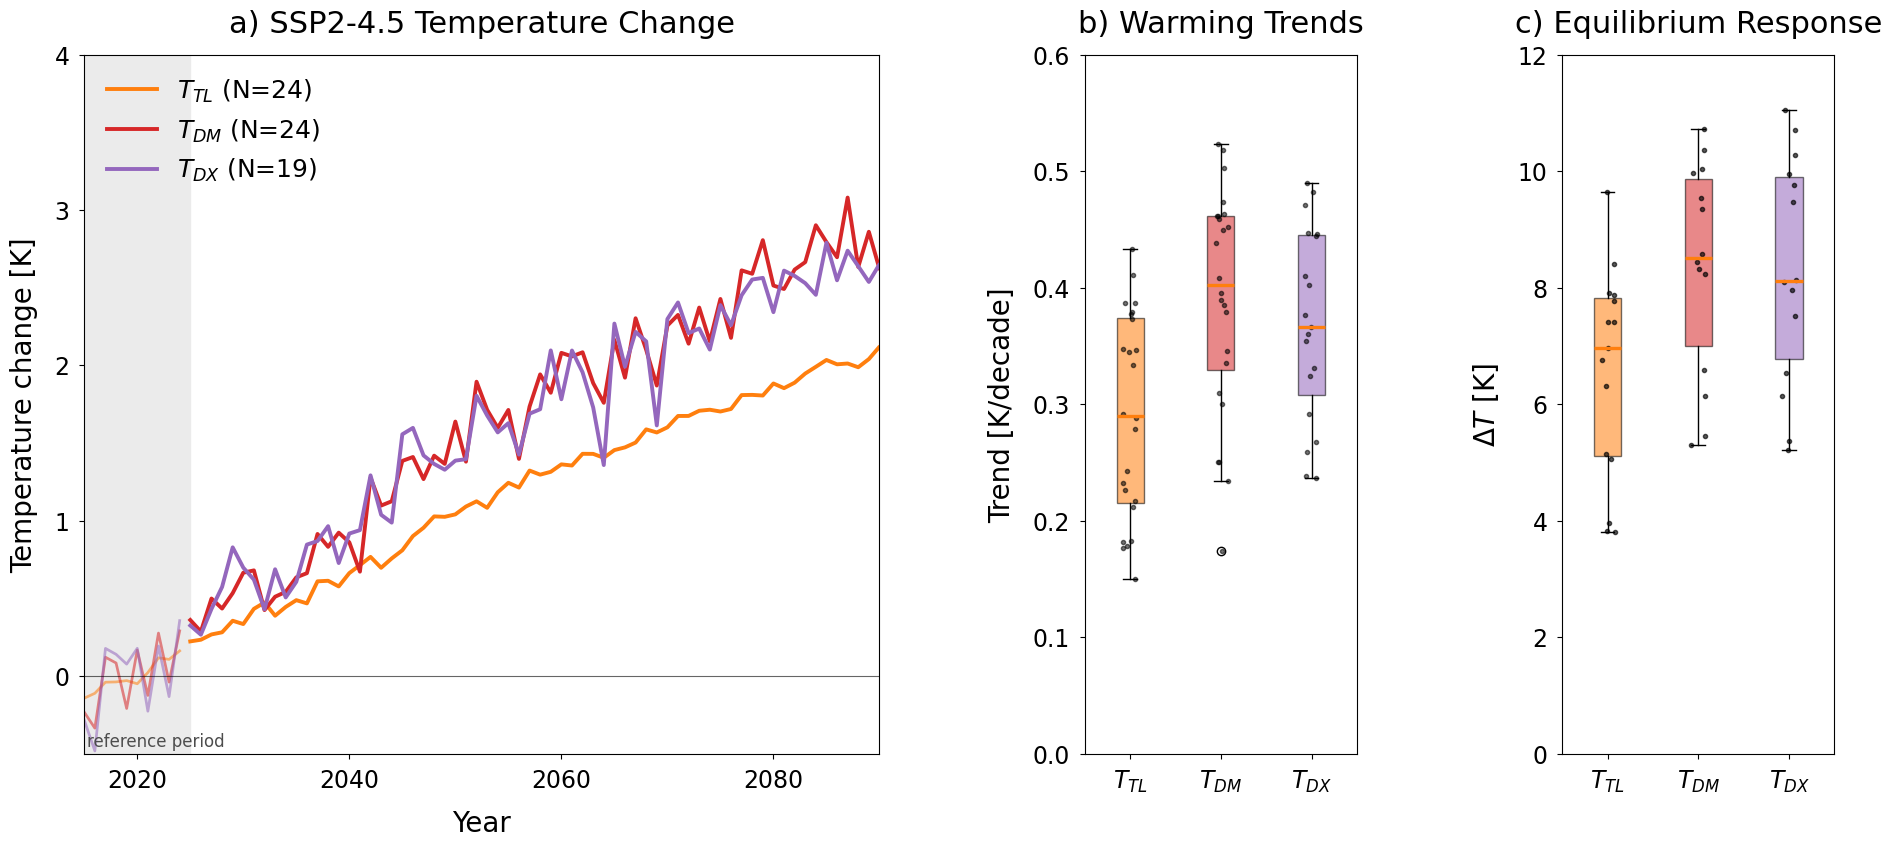

<Figure size 640x480 with 0 Axes>

In [ ]:
# ========= 3-panel figure (GRL-ready, with extra title spacing) =========
# Assumes these dicts already exist in memory:
# TTL_s, TDM_s, TDX_s  -> SSP2-4.5 annual time series per model (2015+)
# TTL_a, TDM_a, TDX_a  -> abrupt4x (for panel c)
# TTL_p, TDM_p, TDX_p  -> piControl (for panel c)

import numpy as np, scipy.stats as ss
import matplotlib.pyplot as plt
from matplotlib import ticker as mticker
from matplotlib import gridspec

# ---------------- Settings ----------------
REFERENCE_PERIOD = (2015, 2024)   # anomaly reference period (shaded in panel a)
B_MAX = 0.60                      # panel (b) upper y-limit
K_FENCE_C = 1.5                   # Tukey fence for panel (c) only (plotting clarity)

# Allowed models (no MPI)
ALLOWED = {
    "ACCESS-CM2","ACCESS-ESM1-5","AWI-CM-1-1-MR","CAMS-CSM1-0","CMCC-CM2-SR5","CMCC-ESM2",
    "CNRM-CM6-1","CNRM-CM6-1-HR","CNRM-ESM2-1","CanESM5","EC-Earth3","EC-Earth3-CC",
    "EC-Earth3-Veg","EC-Earth3-Veg-LR","GFDL-CM4","GFDL-ESM4","HadGEM3-GC31-LL","IITM-ESM",
    "INM-CM4-8","INM-CM5-0","IPSL-CM6A-LR","NorESM2-LM","NorESM2-MM","TaiESM1","UKESM1-0-LL"
}

# ---------------- Helpers ----------------
def pick_L_for_metric(models, store, prefer=85):
    if models and all(len(store[m]) >= prefer for m in models): return prefer
    return min(len(store[m]) for m in models) if models else 0

def anom_first(series, L, ref_period=REFERENCE_PERIOD):
    s = np.asarray(series[:L], float)
    years = np.arange(2015, 2015+L)
    rp = (years >= ref_period[0]) & (years <= ref_period[1])
    base = np.nanmean(s[rp]) if rp.any() else np.nanmean(s[:min(10, s.size)])
    return s - base

def mme_anom_metric(models, store, L):
    A = np.vstack([anom_first(store[m], L) for m in models if len(store[m]) >= L])
    return np.nanmean(A, axis=0) if A.size else np.full(L, np.nan)

def slopes_for_metric(models, store, L):
    t = np.arange(2015, 2015+L)
    out = []
    for m in models:
        y = np.asarray(store[m][:L], float)
        out.append(ss.linregress(t, y).slope * 10.0 if np.isfinite(y).sum() >= 2 else np.nan)
    return np.array(out, float)

def last_mean(a, n=30):
    a = np.asarray(a); n = min(n, len(a))
    return float(np.nanmean(a[-n:])) if n>0 else np.nan

def tukey_mask(values, k=1.5):
    x = np.asarray(values, float)
    q1, q3 = np.nanpercentile(x, 25), np.nanpercentile(x, 75)
    iqr = q3 - q1
    low, high = q1 - k*iqr, q3 + k*iqr
    return (np.isfinite(x) & (x >= low) & (x <= high))

def set_ylim_with_fixed_ticks(ax, ymin, ymax, step):
    ax.set_ylim(ymin, ymax)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(step))

# ---------------- Membership & series ----------------
mods_TL = sorted(ALLOWED & set(TTL_s))
mods_DM = sorted(ALLOWED & set(TDM_s))
mods_DX = sorted(ALLOWED & set(TDX_s))

L_TL = pick_L_for_metric(mods_TL, TTL_s, prefer=85)
L_DM = pick_L_for_metric(mods_DM, TDM_s, prefer=85)
L_DX = pick_L_for_metric(mods_DX, TDX_s, prefer=85)

L_panel = min(L_TL, L_DM, L_DX)
years = np.arange(2015, 2015 + L_panel)

ttl_mme = mme_anom_metric(mods_TL, TTL_s, L_panel)
tdm_mme = mme_anom_metric(mods_DM, TDM_s, L_panel)
tdx_mme = mme_anom_metric(mods_DX, TDX_s, L_panel)

# Panel (b) per-metric trend samples
sl_TL = slopes_for_metric(mods_TL, TTL_s, L_TL)
sl_DM = slopes_for_metric(mods_DM, TDM_s, L_DM)
sl_DX = slopes_for_metric(mods_DX, TDX_s, L_DX)

# Panel (c) abrupt - piControl
ab_common = sorted(
    (set(TTL_a)&set(TDM_a)&set(TDX_a)&set(TTL_p)&set(TDM_p)&set(TDX_p)) & ALLOWED
)
Nc = len(ab_common)
abrupt   = np.full((4, Nc), np.nan)
picontrol= np.full((4, Nc), np.nan)
for i,mod in enumerate(ab_common):
    abrupt[0, i] = last_mean(TDM_a[mod]);  picontrol[0, i] = float(np.nanmean(TDM_p[mod]))
    abrupt[2, i] = last_mean(TTL_a[mod]);  picontrol[2, i] = float(np.nanmean(TTL_p[mod]))
    abrupt[3, i] = last_mean(TDX_a[mod]);  picontrol[3, i] = float(np.nanmean(TDX_p[mod]))
resp = abrupt - picontrol   # rows indices: 2=TL, 0=DM, 3=DX

# ---------------- Plotting ----------------
plt.rcParams.update({
    "font.size": 18, "axes.titlesize": 22, "axes.labelsize": 20,
    "xtick.labelsize": 17, "ytick.labelsize": 17, "legend.fontsize": 18,
    "axes.titlepad": 16, "axes.labelpad": 12   # extra breathing room
})
LW = 2.8
LW_EARLY = LW*0.7
ALPHA_EARLY = 0.55
cs = [(255/255,127/255,14/255), (214/255,39/255,40/255), (148/255,103/255,189/255)]

fig = plt.figure(figsize=(20, 9.2))
gs = gridspec.GridSpec(1, 3, width_ratios=[3.8, 1.3, 1.3])
# more left margin + inter-panel spacing to avoid any overlap between titles and y-ticks
fig.subplots_adjust(left=0.11, right=0.985, top=0.90, bottom=0.14, wspace=0.46)

# --- Panel (a) ---
ax = plt.subplot(gs[0])
ax.set_title("a) SSP2-4.5 Temperature Change", pad=16)
ax.axvspan(REFERENCE_PERIOD[0], REFERENCE_PERIOD[1] + 0.999, color="0.92", zorder=0)
mask_early = (years >= REFERENCE_PERIOD[0]) & (years <= REFERENCE_PERIOD[1])
mask_late  = years > REFERENCE_PERIOD[1]
for series, color, label in [
    (ttl_mme, cs[0], rf"$T_{{TL}}$ (N={len(mods_TL)})"),
    (tdm_mme, cs[1], rf"$T_{{DM}}$ (N={len(mods_DM)})"),
    (tdx_mme, cs[2], rf"$T_{{DX}}$ (N={len(mods_DX)})"),
]:
    ax.plot(years[mask_early], series[mask_early], lw=LW_EARLY, alpha=ALPHA_EARLY, color=color)
    ax.plot(years[mask_late],  series[mask_late],  lw=LW,        alpha=1.0,        color=color, label=label)

ax.axhline(0, color='k', lw=0.8, alpha=0.6)
ax.set_xlabel("Year"); ax.set_ylabel("Temperature change [K]")
ax.set_xlim([years[0], min(years[-1], 2090)])
set_ylim_with_fixed_ticks(ax, ymin=-0.5, ymax=4.0, step=1.0)
ax.set_xticks([2020, 2040, 2060, 2080])
ax.tick_params(pad=7)
ax.text(REFERENCE_PERIOD[0]+0.3, -0.48, "reference period", ha="left", va="bottom",
        fontsize=12, color="0.3")
ax.legend(loc="upper left", ncol=1, frameon=False)

# --- Panel (b) ---
ax2 = plt.subplot(gs[1])
ax2.set_title("b) Warming Trends", pad=16)
bp = ax2.boxplot((sl_TL, sl_DM, sl_DX), patch_artist=True, whis=1)
for box, c in zip(bp['boxes'], cs):
    box.set_facecolor(c); box.set_alpha(0.55)
for med in bp['medians']: med.set_linewidth(2.4)
rng = np.random.default_rng(0)
for i,arr in enumerate((sl_TL, sl_DM, sl_DX), start=1):
    x = np.full(arr.size, i) + rng.uniform(-0.08, 0.08, arr.size)
    ax2.plot(x, arr, ".", ms=6, alpha=0.55, color="k")
ax2.set_ylabel("Trend [K/decade]")
ax2.set_xticks([1,2,3]); ax2.set_xticklabels([r"$T_{TL}$", r"$T_{DM}$", r"$T_{DX}$"])
set_ylim_with_fixed_ticks(ax2, ymin=0.0, ymax=B_MAX, step=0.1)
ax2.tick_params(pad=7)

# --- Panel (c) ---
ax3 = plt.subplot(gs[2])
ax3.set_title("c) Equilibrium Response", pad=16)  # "(outliers removed)" -> caption
labels_c = list(ab_common)[:Nc]
TL_raw = resp[2, :Nc].copy()
DM_raw = resp[0, :Nc].copy()
DX_raw = resp[3, :Nc].copy()

def tukey_filter(values, labels, k=1.5):
    x = np.asarray(values, float)
    mask = tukey_mask(x, k=k)
    removed = [labels[i] for i in np.where(~mask)[0]]
    return x[mask], removed

TL_filt, TL_removed = tukey_filter(TL_raw, labels_c, k=K_FENCE_C)
DM_filt, DM_removed = tukey_filter(DM_raw, labels_c, k=K_FENCE_C)
DX_filt, DX_removed = tukey_filter(DX_raw, labels_c, k=K_FENCE_C)

bp2 = ax3.boxplot((TL_filt, DM_filt, DX_filt), patch_artist=True, whis=1.5, showfliers=False)
for box, c in zip(bp2['boxes'], cs):
    box.set_facecolor(c); box.set_alpha(0.55)
for med in bp2['medians']: med.set_linewidth(2.4)
for i, arr in enumerate((TL_filt, DM_filt, DX_filt), start=1):
    x = np.full(arr.size, i) + rng.uniform(-0.08, 0.08, arr.size)
    ax3.plot(x, arr, ".", ms=6, alpha=0.65, color="k")

ax3.set_ylabel(r"$\Delta T$ [K]")
ax3.set_xticks([1, 2, 3]); ax3.set_xticklabels([r"$T_{TL}$", r"$T_{DM}$", r"$T_{DX}$"])
set_ylim_with_fixed_ticks(ax3, ymin=0.0, ymax=12.0, step=2.0)
ax3.tick_params(pad=7)

plt.show()

plt.savefig("fig1.pdf", bbox_inches="tight")
plt.savefig("fig1.png", dpi=600, bbox_inches="tight")


ABS(TDM) > ABS(TDX) violations (DM∩DX only): []


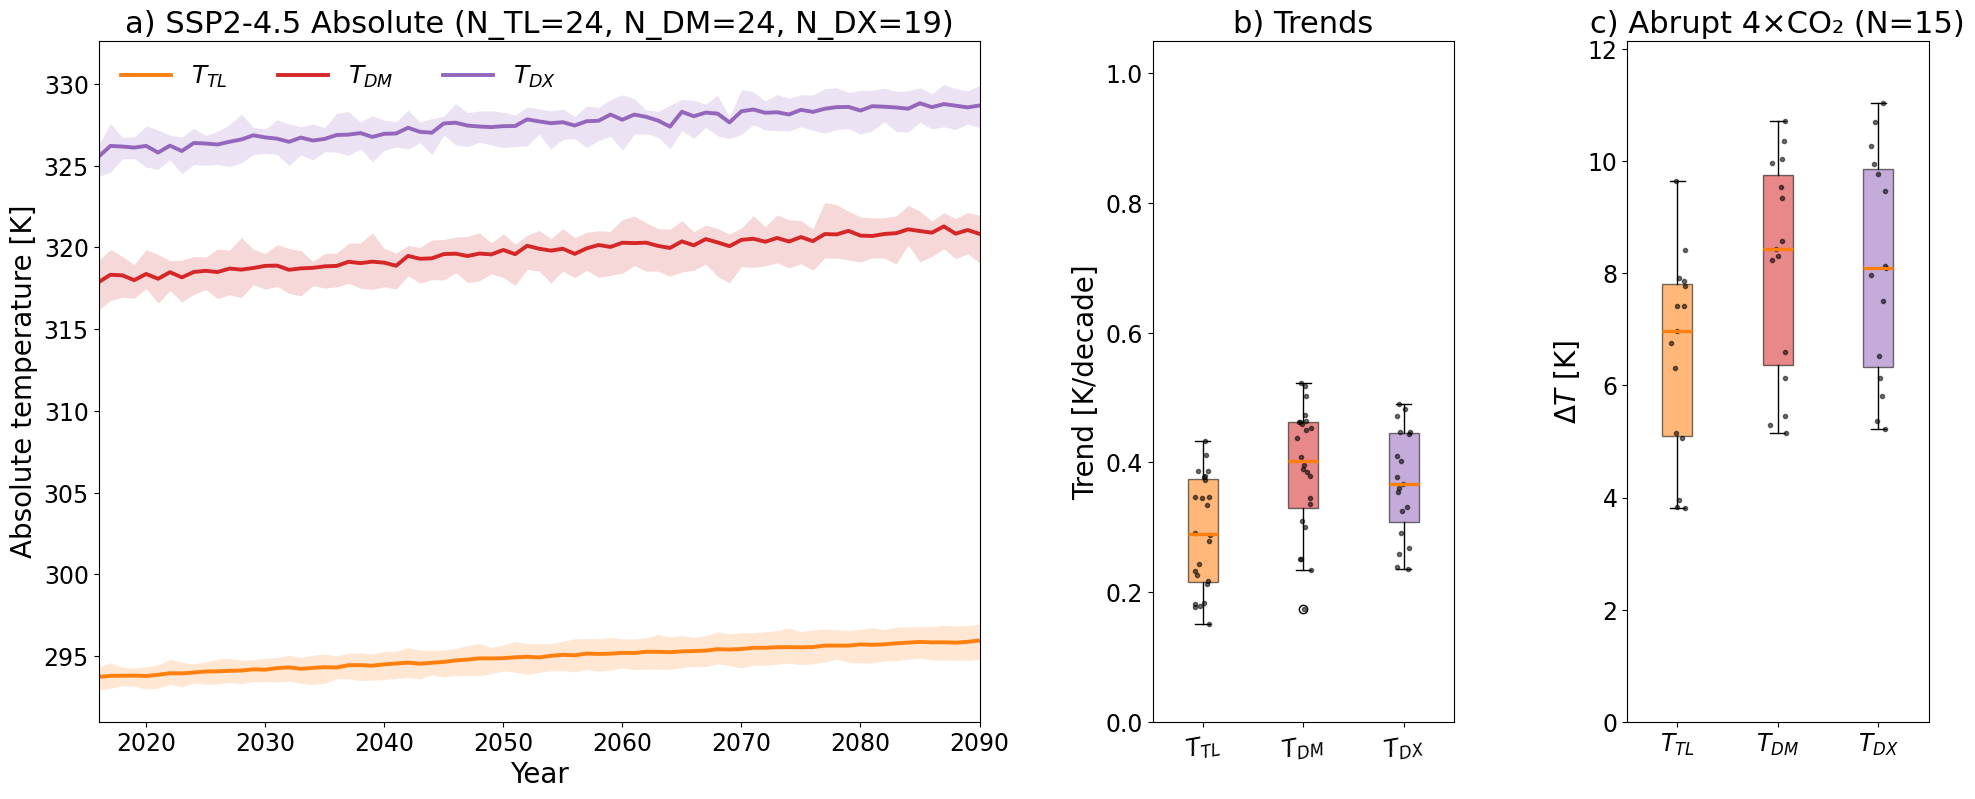

N_TL=24 (L_TL=85), N_DM=24 (L_DM=85), N_DX=19 (L_DX=85)
Median trends [K/dec]  TL, DM, DX = 0.2896085709158013 0.4020307286307053 0.36641148754878006


In [ ]:
# === Absolute panel + spread; include ALL allowed models for TTL, TDM, TDX (exclude MPI) ===
import numpy as np, matplotlib.pyplot as plt
from matplotlib import gridspec
import scipy.stats as ss

# ---- 0) Allowed list (exclude MPI) ----
ALLOWED = {
    "ACCESS-CM2","ACCESS-ESM1-5","AWI-CM-1-1-MR","CAMS-CSM1-0","CMCC-CM2-SR5","CMCC-ESM2",
    "CNRM-CM6-1","CNRM-CM6-1-HR","CNRM-ESM2-1","CanESM5","EC-Earth3","EC-Earth3-CC",
    "EC-Earth3-Veg","EC-Earth3-Veg-LR","GFDL-CM4","GFDL-ESM4","HadGEM3-GC31-LL","IITM-ESM",
    "INM-CM4-8","INM-CM5-0","IPSL-CM6A-LR","NorESM2-LM","NorESM2-MM","TaiESM1","UKESM1-0-LL"
}

# ---- 1) Per-metric ensembles: include ALL allowed models that exist for each metric ----
mods_TL = sorted(ALLOWED & set(TTL_s))
mods_DM = sorted(ALLOWED & set(TDM_s))
mods_DX = sorted(ALLOWED & set(TDX_s))

def pick_L_metric(models, store, prefer=85):
    if models and all(len(store[m]) >= prefer for m in models):
        return prefer
    return min(len(store[m]) for m in models) if models else 0

L_TL = pick_L_metric(mods_TL, TTL_s, prefer=85)
L_DM = pick_L_metric(mods_DM, TDM_s, prefer=85)
L_DX = pick_L_metric(mods_DX, TDX_s, prefer=85)

# Shared time axis for panel (a) so curves overlay
L_panel = min([x for x in [L_TL, L_DM, L_DX] if x > 0])
yrs      = np.arange(2015, 2015+L_panel)

# ---- 2) Build absolute stacks for panel (a) + IQR (truncate each ensemble to L_panel) ----
def stack_truncate(models, store, L):
    return np.vstack([np.asarray(store[m][:L], float) for m in models if len(store[m]) >= L])

TTL_mat = stack_truncate(mods_TL, TTL_s, L_panel)
TDM_mat = stack_truncate(mods_DM, TDM_s, L_panel)
TDX_mat = stack_truncate(mods_DX, TDX_s, L_panel)

def mean_iqr(A):
    mme = np.nanmean(A, axis=0)
    q25 = np.nanpercentile(A, 25, axis=0)
    q75 = np.nanpercentile(A, 75, axis=0)
    return mme, q25, q75

ttl_mean, ttl_q25, ttl_q75 = mean_iqr(TTL_mat)
tdm_mean, tdm_q25, tdm_q75 = mean_iqr(TDM_mat)
tdx_mean, tdx_q25, tdx_q75 = mean_iqr(TDX_mat)

# ---- 3) Trends (K/decade) per metric using their own L and ensemble ----
def slopes_for_metric(models, store, L):
    t = np.arange(2015, 2015+L)
    out = []
    for m in models:
        y = np.asarray(store[m][:L], float)
        if np.isfinite(y).sum() >= 2:
            out.append(ss.linregress(t, y).slope * 10.0)
        else:
            out.append(np.nan)
    return np.array(out, float)

sl_TL = slopes_for_metric(mods_TL, TTL_s, L_TL)
sl_DM = slopes_for_metric(mods_DM, TDM_s, L_DM)
sl_DX = slopes_for_metric(mods_DX, TDX_s, L_DX)

# ---- 4) Abrupt − piControl on its OWN allowed common set (independent) ----
ab_common = sorted(
    (set(TTL_a)&set(TDM_a)&set(TDX_a)&set(TTL_p)&set(TDM_p)&set(TDX_p)) & ALLOWED
)

def last_mean(a, n=30):
    a = np.asarray(a); n = min(n, len(a));
    return float(np.nanmean(a[-n:])) if n>0 else np.nan

resp_TTL = np.array([last_mean(TTL_a[m]) - float(np.nanmean(TTL_p[m])) for m in ab_common])
resp_TDM = np.array([last_mean(TDM_a[m]) - float(np.nanmean(TDM_p[m])) for m in ab_common])
resp_TDX = np.array([last_mean(TDX_a[m]) - float(np.nanmean(TDX_p[m])) for m in ab_common])

# ---- 5) Optional sanity: compare DM vs DX only where both exist over shared length ----
dm_dx_common = sorted(set(mods_DM) & set(mods_DX))
L_check = min(L_DM, L_DX)
viol = [
    (m, int(np.sum(np.asarray(TDM_s[m][:L_check]) > np.asarray(TDX_s[m][:L_check]))))
    for m in dm_dx_common if np.any(np.asarray(TDM_s[m][:L_check]) > np.asarray(TDX_s[m][:L_check]))
]
print("ABS(TDM) > ABS(TDX) violations (DM∩DX only):", viol)  # ideally []

# ---- 6) Plot ----
plt.rcParams.update({
    "font.size": 18, "axes.titlesize": 22, "axes.labelsize": 20,
    "xtick.labelsize": 17, "ytick.labelsize": 17, "legend.fontsize": 18
})
LW = 2.8
cs = [(255,127,14), (214,39,40), (148,103,189)]
cs = [(r/255., g/255., b/255.) for r,g,b in cs]
rng = np.random.default_rng(0)

fig = plt.figure(figsize=(20, 9.2))
gs = gridspec.GridSpec(1, 3, width_ratios=[3.8, 1.3, 1.3])
fig.subplots_adjust(left=0.07, right=0.985, top=0.90, bottom=0.16, wspace=0.35)

# (a) ABSOLUTE temperatures + IQR shading (ALL allowed per metric; aligned to L_panel)
ax = plt.subplot(gs[0])
ax.set_title(f"a) SSP2-4.5 Absolute (N_TL={len(mods_TL)}, N_DM={len(mods_DM)}, N_DX={len(mods_DX)})")
for mean,q25,q75, col, lab in [
    (ttl_mean, ttl_q25, ttl_q75, cs[0], r"$T_{TL}$"),
    (tdm_mean, tdm_q25, tdm_q75, cs[1], r"$T_{DM}$"),
    (tdx_mean, tdx_q25, tdx_q75, cs[2], r"$T_{DX}$"),
]:
    ax.fill_between(yrs, q25, q75, color=col, alpha=0.18, linewidth=0)
    ax.plot(yrs, mean, lw=LW, color=col, label=lab)
ax.set_xlabel("Year"); ax.set_ylabel("Absolute temperature [K]")
ax.set_xlim([max(yrs[0]+1, 2016), min(yrs[-1], 2090)])
ax.legend(loc="upper left", ncol=3, frameon=False)

# (b) Trends (per-metric ensembles; show their Ns and Ls)
ax2 = plt.subplot(gs[1])
ax2.set_title("b) Trends")
data_tr = (sl_TL, sl_DM, sl_TDX)
bp = ax2.boxplot(data_tr, patch_artist=True, whis=1)
for box, c in zip(bp['boxes'], cs): box.set_facecolor(c); box.set_alpha(0.55)
for med in bp['medians']: med.set_linewidth(2.4)
for i,arr in enumerate(data_tr, start=1):
    x = np.full(arr.size, i) + rng.uniform(-0.08, 0.08, arr.size)
    ax2.plot(x, arr, ".", ms=6, alpha=0.55, color="k")
ax2.set_xticks([1,2,3])
ax2.set_xticklabels([rf"$T_{{TL}}$",
                     rf"$T_{{DM}}$",
                     rf"$T_{{DX}}$"], rotation=10)
ax2.set_ylim(0, max(1.05, np.nanmax(np.concatenate([np.nan_to_num(sl_TL, nan=0),
                                                     np.nan_to_num(sl_DM, nan=0),
                                                     np.nan_to_num(sl_DX, nan=0)]))*1.1))
ax2.set_ylabel("Trend [K/decade]")

# (c) Abrupt 4×CO₂ response (last30 − piControl), independent allowed common set
ax3 = plt.subplot(gs[2])
ax3.set_title(f"c) Abrupt 4×CO₂ (N={len(ab_common)})")
data_ab = (resp_TTL, resp_TDM, resp_TDX)
bp2 = ax3.boxplot(data_ab, patch_artist=True, whis=2)
for box, c in zip(bp2['boxes'], cs): box.set_facecolor(c); box.set_alpha(0.55)
for med in bp2['medians']: med.set_linewidth(2.4)
for i,arr in enumerate(data_ab, start=1):
    x = np.full(arr.size, i) + rng.uniform(-0.08, 0.08, arr.size)
    ax3.plot(x, arr, ".", ms=6, alpha=0.55, color="k")
ax3.set_xticks([1,2,3]); ax3.set_xticklabels([r"$T_{TL}$", r"$T_{DM}$", r"$T_{DX}$"])
ax3.set_ylabel(r"$\Delta T$ [K]")
ax3.set_ylim(0, max(10.5, np.nanmax(np.concatenate(data_ab))*1.1))

plt.show()

print(f"N_TL={len(mods_TL)} (L_TL={L_TL}), N_DM={len(mods_DM)} (L_DM={L_DM}), N_DX={len(mods_DX)} (L_DX={L_DX})")
print("Median trends [K/dec]  TL, DM, DX =",
      np.nanmedian(sl_TL), np.nanmedian(sl_DM), np.nanmedian(sl_DX))


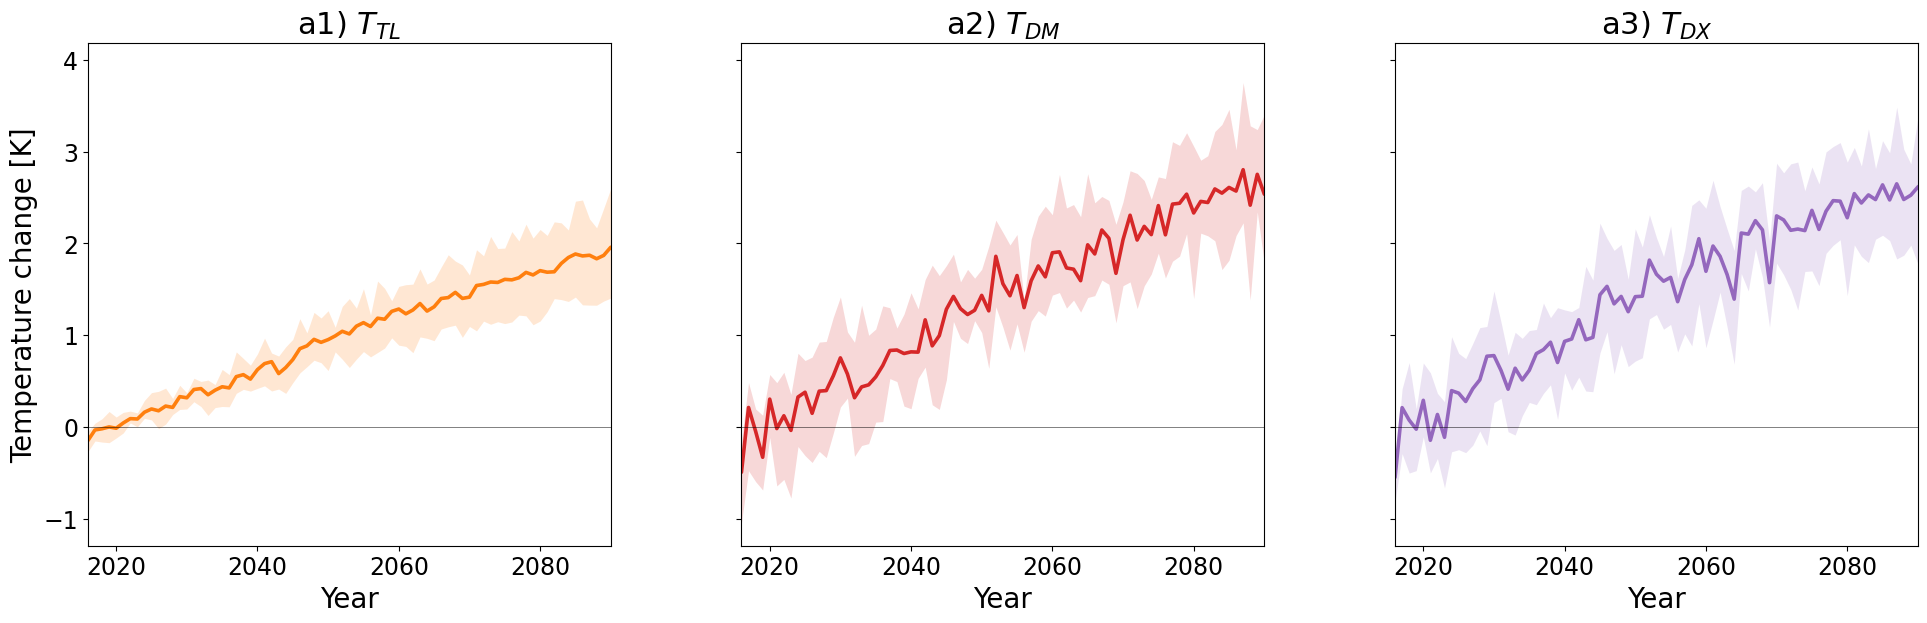

In [ ]:
# --- Split time-evolution into 3 subpanels with model spread ---
import numpy as np
import matplotlib.pyplot as plt

# Choose what to plot
ABSOLUTE = False   # set to False to plot temp change instead
BASE = 10         # anomaly baseline length (only used if ABSOLUTE == False)

# colors + line width
cs = [(255/255,127/255,14/255), (214/255,39/255,40/255), (148/255,103/255,189/255)]
LW = 2.6
N = len(ssp_common)  # common models used in TTL_mat/TDM_mat/TDX_mat

def mean_iqr(A):
    mme = np.nanmean(A, axis=0)
    q25 = np.nanpercentile(A, 25, axis=0)
    q75 = np.nanpercentile(A, 75, axis=0)
    return mme, q25, q75

def to_anom(M, base_len):
    base = np.nanmean(M[:, :min(base_len, M.shape[1])], axis=1, keepdims=True)
    return M - base

# pick absolute vs anomaly matrices
TTL_plot = TTL_mat if ABSOLUTE else to_anom(TTL_mat, BASE)
TDM_plot = TDM_mat if ABSOLUTE else to_anom(TDM_mat, BASE)
TDX_plot = TDX_mat if ABSOLUTE else to_anom(TDX_mat, BASE)

# stats for each
ttl_m, ttl_q25, ttl_q75 = mean_iqr(TTL_plot)
tdm_m, tdm_q25, tdm_q75 = mean_iqr(TDM_plot)
tdx_m, tdx_q25, tdx_q75 = mean_iqr(TDX_plot)

# unified y-limits so all three panels are comparable
ymin = float(min(ttl_q25.min(), tdm_q25.min(), tdx_q25.min()))
ymax = float(max(ttl_q75.max(), tdm_q75.max(), tdx_q75.max()))
pad  = 0.25 if ABSOLUTE else 0.25
ymin, ymax = ymin - pad, ymax + pad

# figure
plt.rcParams.update({
    "font.size": 18, "axes.titlesize": 22, "axes.labelsize": 20,
    "xtick.labelsize": 17, "ytick.labelsize": 17
})
fig, axs = plt.subplots(1, 3, sharey=True, figsize=(20, 6.8))
fig.subplots_adjust(left=0.07, right=0.985, top=0.90, bottom=0.16, wspace=0.25)

ylabel = "Absolute temperature [K]" if ABSOLUTE else "Temperature change [K]"
supt = "Absolute (common set)" if ABSOLUTE else f"Anomalies (baseline={BASE} yrs, common set)"


# a1) TTL
ax = axs[0]
ax.set_title(r"a1) $T_{TL}$")
ax.fill_between(yrs, ttl_q25, ttl_q75, color=cs[0], alpha=0.18, lw=0)
ax.plot(yrs, ttl_m, color=cs[0], lw=LW)
ax.set_xlim([max(yrs[0]+1, 2016), min(yrs[-1], 2090)])
ax.set_ylim([ymin, ymax])
ax.set_xlabel("Year"); ax.set_ylabel(ylabel)
ax.axhline(0, color='k', lw=0.7, alpha=0.5) if not ABSOLUTE else None
ax.set_xticks([2020, 2040, 2060, 2080])

# a2) TDM
ax = axs[1]
ax.set_title(r"a2) $T_{DM}$")
ax.fill_between(yrs, tdm_q25, tdm_q75, color=cs[1], alpha=0.18, lw=0)
ax.plot(yrs, tdm_m, color=cs[1], lw=LW)
ax.set_xlim([max(yrs[0]+1, 2016), min(yrs[-1], 2090)])
ax.set_ylim([ymin, ymax])
ax.set_xlabel("Year")
ax.axhline(0, color='k', lw=0.7, alpha=0.5) if not ABSOLUTE else None
ax.set_xticks([2020, 2040, 2060, 2080])

# a3) TDX
ax = axs[2]
ax.set_title(r"a3) $T_{DX}$")
ax.fill_between(yrs, tdx_q25, tdx_q75, color=cs[2], alpha=0.18, lw=0)
ax.plot(yrs, tdx_m, color=cs[2], lw=LW)
ax.set_xlim([max(yrs[0]+1, 2016), min(yrs[-1], 2090)])
ax.set_ylim([ymin, ymax])
ax.set_xlabel("Year")
ax.axhline(0, color='k', lw=0.7, alpha=0.5) if not ABSOLUTE else None
ax.set_xticks([2020, 2040, 2060, 2080])

plt.show()


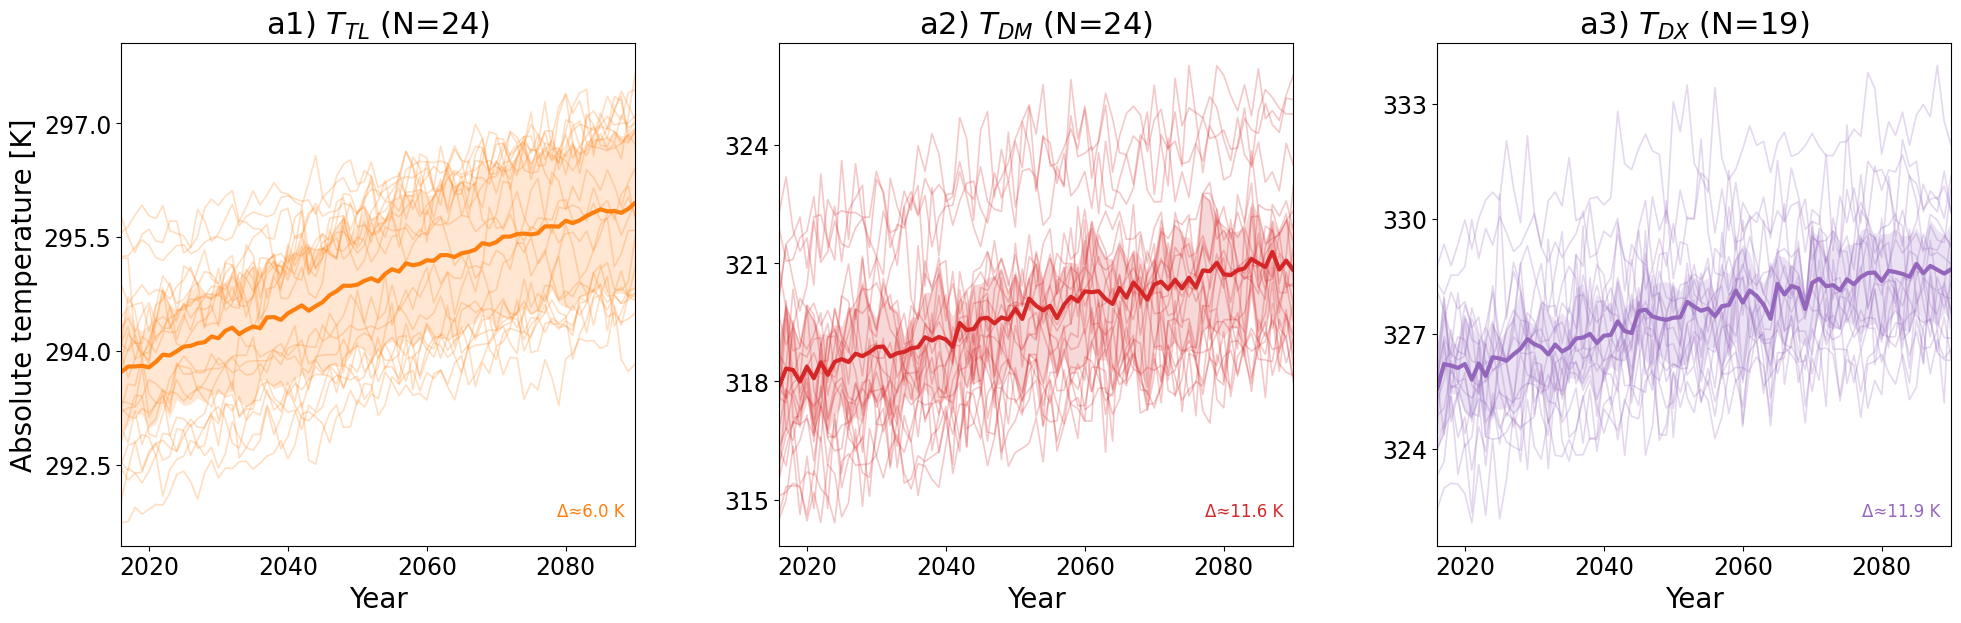

In [ ]:
# --- Split time-evolution into 3 subpanels (ABSOLUTE) with per-panel y-scales ---
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

ABSOLUTE = True   # we’re plotting absolute temps
LW_mean = 3.0
LW_spag = 1.2
ALPHA_SPAG = 0.25
cs = [(255/255,127/255,14/255), (214/255,39/255,40/255), (148/255,103/255,189/255)]

# Expect: TTL_mat, TDM_mat, TDX_mat (n_model x L) and yrs

def mean_iqr(A):
    mme = np.nanmean(A, axis=0)
    q25 = np.nanpercentile(A, 25, axis=0)
    q75 = np.nanpercentile(A, 75, axis=0)
    return mme, q25, q75

TTL_plot, TDM_plot, TDX_plot = TTL_mat, TDM_mat, TDX_mat
ttl_m, ttl_q25, ttl_q75 = mean_iqr(TTL_plot)
tdm_m, tdm_q25, tdm_q75 = mean_iqr(TDM_plot)
tdx_m, tdx_q25, tdx_q75 = mean_iqr(TDX_plot)

def panel(ax, years, M, q25, q75, mean_line, color, title, ylabel=None):
    # spaghetti
    for i in range(M.shape[0]):
        ax.plot(years, M[i], color=color, lw=LW_spag, alpha=ALPHA_SPAG)
    # IQR + mean
    ax.fill_between(years, q25, q75, color=color, alpha=0.18, lw=0)
    ax.plot(years, mean_line, color=color, lw=LW_mean)
    ax.set_title(title)
    ax.set_xlim([max(years[0]+1, 2016), min(years[-1], 2090)])
    ax.set_xlabel("Year")
    if ylabel: ax.set_ylabel(ylabel)
    ax.set_xticks([2020, 2040, 2060, 2080])
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    # per-panel y-lims (based on spaghetti min/max with a bit of padding)
    y_lo = float(np.nanmin(M))
    y_hi = float(np.nanmax(M))
    pad = 0.05 * (y_hi - y_lo if y_hi > y_lo else 1.0)
    ax.set_ylim(y_lo - pad, y_hi + pad)

    # annotate the vertical range to make scales obvious
    rng = y_hi - y_lo
    ax.text(0.98, 0.05, f"Δ≈{rng:.1f} K", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=12, color=color)

plt.rcParams.update({
    "font.size": 18, "axes.titlesize": 22, "axes.labelsize": 20,
    "xtick.labelsize": 17, "ytick.labelsize": 17
})

fig, axs = plt.subplots(1, 3, figsize=(20, 6.8))  # no sharey → independent “temperature bars”
fig.subplots_adjust(left=0.07, right=0.985, top=0.90, bottom=0.16, wspace=0.28)

# a1) TTL
panel(axs[0], yrs, TTL_plot, ttl_q25, ttl_q75, ttl_m, cs[0], rf"a1) $T_{{TL}}$ (N={TTL_plot.shape[0]})",
      ylabel="Absolute temperature [K]")

# a2) TDM
panel(axs[1], yrs, TDM_plot, tdm_q25, tdm_q75, tdm_m, cs[1], rf"a2) $T_{{DM}}$ (N={TDM_plot.shape[0]})")

# a3) TDX
panel(axs[2], yrs, TDX_plot, tdx_q25, tdx_q75, tdx_m, cs[2], rf"a3) $T_{{DX}}$ (N={TDX_plot.shape[0]})")

plt.show()


In [ ]:
# --- Per-model trend table for TL / DM / DX (2015–2099) ---
import numpy as np, pandas as pd, scipy.stats as ss
import matplotlib.pyplot as plt

# 1) Configuration (edit if needed)
START, END = 2015, 2099
MIN_YEARS  = 85   # require full SSP window
TIME = np.arange(START, END+1)

# Optional: restrict to your allowed model list
ALLOWED = {
    "ACCESS-CM2","ACCESS-ESM1-5","AWI-CM-1-1-MR","CAMS-CSM1-0","CMCC-CM2-SR5","CMCC-ESM2",
    "CNRM-CM6-1","CNRM-CM6-1-HR","CNRM-ESM2-1","CanESM5","EC-Earth3","EC-Earth3-CC",
    "EC-Earth3-Veg","EC-Earth3-Veg-LR","GFDL-CM4","GFDL-ESM4","HadGEM3-GC31-LL","IITM-ESM",
    "INM-CM4-8","INM-CM5-0","IPSL-CM6A-LR","NorESM2-LM","NorESM2-MM","TaiESM1","UKESM1-0-LL"
}

# 2) Choose ensembles (same logic as your plots)
def has_len(d, m, n): return (m in d) and (len(d[m]) >= n)
mods_TLDM = sorted([m for m in (set(TTL_s) & set(TDM_s)) & ALLOWED if has_len(TTL_s, m, MIN_YEARS) and has_len(TDM_s, m, MIN_YEARS)])
mods_DX   = sorted([m for m in (set(TDX_s) & ALLOWED) if has_len(TDX_s, m, MIN_YEARS)])
all_mods  = sorted(set(mods_TLDM) | set(mods_DX))

print(f"N_TL/DM={len(mods_TLDM)}, N_DX={len(mods_DX)}, union={len(all_mods)}")

# 3) Helper: linear trend (K/decade)
def trend_per_decade(series, years=TIME):
    y = np.array(series[:len(years)], dtype=float)
    mask = np.isfinite(y)
    if mask.sum() < 2: return np.nan
    return ss.linregress(years[mask], y[mask]).slope * 10.0

# 4) Build the table
rows = []
for m in all_mods:
    tl = trend_per_decade(TTL_s[m]) if m in mods_TLDM else np.nan
    dm = trend_per_decade(TDM_s[m]) if m in mods_TLDM else np.nan
    dx = trend_per_decade(TDX_s[m]) if m in mods_DX   else np.nan
    rows.append({
        "model": m,
        "trend_TL_K_per_dec": tl,
        "trend_DM_K_per_dec": dm,
        "trend_DX_K_per_dec": dx,
        "DM_over_TL": (dm / tl) if np.isfinite(dm) and np.isfinite(tl) and tl != 0 else np.nan,
        "DX_over_TL": (dx / tl) if np.isfinite(dx) and np.isfinite(tl) and tl != 0 else np.nan,
        "in_TLDM": m in mods_TLDM,
        "in_DX":   m in mods_DX,
    })

df_trends = pd.DataFrame(rows).sort_values("model").reset_index(drop=True)
display(df_trends.style.format({
    "trend_TL_K_per_dec": "{:.3f}",
    "trend_DM_K_per_dec": "{:.3f}",
    "trend_DX_K_per_dec": "{:.3f}",
    "DM_over_TL": "{:.2f}",
    "DX_over_TL": "{:.2f}",
}))

print("\nMedian trends [K/dec] over their available ensembles:")
print("  TL:", np.nanmedian(df_trends["trend_TL_K_per_dec"]))
print("  DM:", np.nanmedian(df_trends["trend_DM_K_per_dec"]))
print("  DX:", np.nanmedian(df_trends["trend_DX_K_per_dec"]))



N_TL/DM=24, N_DX=19, union=24


,model,trend_TL_K_per_dec,trend_DM_K_per_dec,trend_DX_K_per_dec,DM_over_TL,DX_over_TL,in_TLDM,in_DX
0,ACCESS-CM2,0.373,0.474,0.410,1.27,1.10,True,True
1,AWI-CM-1-1-MR,0.243,0.250,0.268,1.03,1.10,True,True
2,CAMS-CSM1-0,0.181,0.234,0.236,1.29,1.30,True,True
3,CMCC-CM2-SR5,0.347,0.452,nan,1.30,nan,True,False
4,CMCC-ESM2,0.387,0.463,0.447,1.20,1.15,True,True
5,CNRM-CM6-1,0.346,0.449,0.446,1.30,1.29,True,True
6,CNRM-CM6-1-HR,0.379,0.503,nan,1.33,nan,True,False
7,CNRM-ESM2-1,0.334,0.459,0.471,1.38,1.41,True,True
8,CanESM5,0.378,0.438,0.403,1.16,1.07,True,True
9,EC-Earth3,0.288,0.385,0.355,1.34,1.23,True,True



Median trends [K/dec] over their available ensembles:
  TL: 0.2896085709158013
  DM: 0.4020307286307053
  DX: 0.36641148754878006


In [11]:
# ===================== HIST(2005–2014) + SSP245 CONCAT (LAND-ONLY) =====================
import intake, xarray as xr, numpy as np
from pathlib import Path

# ---------------- Configuration ----------------
REFERENCE_PERIOD = (2005, 2014)   # anomaly baseline (all-historical)
SSP_START = 2015
OUTDIR = Path("./cmip6_metrics_concat")   # where npy files will be saved
OUTDIR.mkdir(parents=True, exist_ok=True)

STORAGE_OPTS = {"token": "anon"}
PREF = ["r1i1p1f1","r1i1p1f2","r1i1p1f3","r1i1p1f4"]
STRICT_LAND = True  # require sftlf to mask land

# Allowed models (same as your table)
TABLE_MODELS = [
    "ACCESS-CM2","ACCESS-ESM1-5","AWI-CM-1-1-MR","CAMS-CSM1-0","CMCC-CM2-SR5","CMCC-ESM2",
    "CNRM-CM6-1","CNRM-CM6-1-HR","CNRM-ESM2-1","CanESM5","EC-Earth3","EC-Earth3-CC",
    "EC-Earth3-Veg","EC-Earth3-Veg-LR","GFDL-CM4","GFDL-ESM4","HadGEM3-GC31-LL","IITM-ESM",
    "INM-CM4-8","INM-CM5-0","IPSL-CM6A-LR","NorESM2-LM","NorESM2-MM","TaiESM1","UKESM1-0-LL"
]

# ---------------- Catalog ----------------
cat = intake.open_esm_datastore("https://storage.googleapis.com/cmip6/pangeo-cmip6.json")
df = cat.df

def _best_one(dfi):
    if dfi.empty: return None
    g = dfi.copy()
    g["pref_rank"] = g["member_id"].apply(lambda m: PREF.index(m) if m in PREF else 999)
    return g.sort_values(["pref_rank","version"], ascending=[True, False]).iloc[0]

# Pair historical+ssp245, preferring the SAME member_id when possible
def paired_lookup_day(var, models=None, exp_hist="historical", exp_ssp="ssp245"):
    d_hist = df[(df.variable_id==var)&(df.table_id=="day")&(df.experiment_id==exp_hist)&
                (df.source_id.isin(TABLE_MODELS if models is None else models))].copy()
    d_ssp  = df[(df.variable_id==var)&(df.table_id=="day")&(df.experiment_id==exp_ssp)&
                (df.source_id.isin(TABLE_MODELS if models is None else models))].copy()
    out = {}
    for m in sorted(set(d_hist.source_id) & set(d_ssp.source_id)):
        H = d_hist[d_hist.source_id==m].copy()
        S = d_ssp [d_ssp .source_id==m].copy()
        # try to keep the same member
        overlap = sorted(set(H.member_id) & set(S.member_id),
                         key=lambda r: (PREF.index(r) if r in PREF else 999, r))
        if overlap:
            mem = overlap[0]
            hrow = H[H.member_id==mem].sort_values(["version"], ascending=False).iloc[0]
            srow = S[S.member_id==mem].sort_values(["version"], ascending=False).iloc[0]
        else:
            hrow = _best_one(H); srow = _best_one(S)
        out[m] = dict(
            model=m,
            hist=dict(zstore=hrow.zstore, model=m, grid=hrow.grid_label, member=hrow.member_id, exp=exp_hist),
            ssp =dict(zstore=srow.zstore, model=m, grid=srow.grid_label, member=srow.member_id, exp=exp_ssp),
        )
    return out

pairs_tas    = paired_lookup_day("tas",    TABLE_MODELS)
pairs_tasmax = paired_lookup_day("tasmax", TABLE_MODELS)

# ---------------- I/O helpers ----------------
def open_zarr(zurl):
    # consolidated first; fall back if needed; cftime-safe decode
    try:
        return xr.open_zarr(zurl, consolidated=True,  storage_options=STORAGE_OPTS, decode_times=True, use_cftime=True)
    except Exception:
        return xr.open_zarr(zurl, consolidated=False, storage_options=STORAGE_OPTS, decode_times=True, use_cftime=True)

# ---------------- Land mask ----------------
def _fx_lookup():
    dfx = df[(df.variable_id=="sftlf")&(df.table_id=="fx")].copy()
    L = {}
    for (m,g), sub in dfx.groupby(["source_id","grid_label"]):
        r = _best_one(sub)
        if r is not None: L[(m,g)] = dict(zstore=r.zstore)
    return L

FX = _fx_lookup()

def land_mask(model, grid):
    key=(model,grid)
    if key in FX:
        ds=open_zarr(FX[key]["zstore"])
        if "sftlf" in ds:
            m = ds["sftlf"]
            if "time" in m.dims: m = m.isel(time=0)
            return (m>50)
    return None

def _broadcast_land_mask(da, model, grid):
    lm = land_mask(model, grid)
    if lm is None:
        if STRICT_LAND:
            raise RuntimeError(f"No sftlf land mask for {model}[{grid}]")
        return None
    return lm.broadcast_like(da.isel(time=0, drop=True))

def global_weighted(da):
    w = np.cos(np.deg2rad(da["lat"]))
    return da.weighted(w).mean(("lat","lon"), skipna=True)

# ---------------- Metric definitions (same as your corrected ones) ----------------
# TDM = annual max of the daily spatial max of tas (land-only)
def TDM_max_anywhere_tas_day(meta):
    ds  = open_zarr(meta["zstore"])
    tas = ds["tas"].chunk({"time":60})
    lm  = _broadcast_land_mask(tas, meta["model"], meta.get("grid",""))
    if lm is not None:
        tas = tas.where(lm)
    daily_spatial_max = tas.max(("lat","lon"), skipna=True)
    return daily_spatial_max.groupby("time.year").max("time", skipna=True).rename({"year":"year"})

# TDX = annual max of the daily spatial max of tasmax (land-only)
def TDX_max_anywhere_tasmax_day(meta):
    ds  = open_zarr(meta["zstore"])
    tmx = ds["tasmax"].chunk({"time":60})
    lm  = _broadcast_land_mask(tmx, meta["model"], meta.get("grid",""))
    if lm is not None:
        tmx = tmx.where(lm)
    daily_spatial_max = tmx.max(("lat","lon"), skipna=True)
    return daily_spatial_max.groupby("time.year").max("time", skipna=True).rename({"year":"year"})

# TTL = tropical land (45S–45N) annual mean (land-only)
def TTL_tropical_land_tas_day(meta):
    ds  = open_zarr(meta["zstore"])
    tas = ds["tas"].sel(lat=slice(-45,45)).chunk({"time":60})
    lm  = land_mask(meta["model"], meta.get("grid",""))
    if lm is not None:
        lm = lm.sel(lat=slice(-45,45)).broadcast_like(tas.isel(time=0, drop=True))
        tas = tas.where(lm)
    gm = global_weighted(tas)
    return gm.groupby("time.year").mean("time", skipna=True).rename({"year":"year"})

# ---------------- Concat logic ----------------
def _hist_tail(da, start=2005, end=2014):
    # da has "year" coordinate
    return da.sel(year=slice(start, end))

def _ssp_keep(da, start=SSP_START):
    return da.sel(year=slice(start, None))

def concat_hist_then_ssp(metric_fn, meta_hist, meta_ssp, hist_window=(2005,2014), ssp_start=SSP_START):
    # compute annual metric for each experiment
    yH = metric_fn(meta_hist)
    yS = metric_fn(meta_ssp)
    if "year" not in yH.coords: yH = yH.rename({"time":"year"})
    if "year" not in yS.coords: yS = yS.rename({"time":"year"})
    tail = _hist_tail(yH, *hist_window)
    ssp  = _ssp_keep(yS, start=ssp_start)
    combined = xr.concat([tail, ssp], dim="year")
    return combined

def _save_vec_and_years(da, path_base):
    # da: 1D over 'year'
    np.save(path_base + ".npy", da.compute().values)
    np.save(path_base + "_years.npy", da["year"].values.astype(int))

# ---------------- Build & save for all models ----------------
saved = {"TTL":0,"TDM":0,"TDX":0}

for m, pair in pairs_tas.items():
    try:
        ttl = concat_hist_then_ssp(TTL_tropical_land_tas_day, pair["hist"], pair["ssp"],
                                   hist_window=(2005,2014), ssp_start=SSP_START)
        _save_vec_and_years(ttl, str(OUTDIR / f"{m}_hist2005-2014+ssp245_TTL"))
        saved["TTL"] += 1

        tdm = concat_hist_then_ssp(TDM_max_anywhere_tas_day, pair["hist"], pair["ssp"],
                                   hist_window=(2005,2014), ssp_start=SSP_START)
        _save_vec_and_years(tdm, str(OUTDIR / f"{m}_hist2005-2014+ssp245_TDM"))
        saved["TDM"] += 1
    except Exception as e:
        print("TTL/TDM fail", m, e)

for m, pair in pairs_tasmax.items():
    try:
        tdx = concat_hist_then_ssp(TDX_max_anywhere_tasmax_day, pair["hist"], pair["ssp"],
                                   hist_window=(2005,2014), ssp_start=SSP_START)
        _save_vec_and_years(tdx, str(OUTDIR / f"{m}_hist2005-2014+ssp245_TDX"))
        saved["TDX"] += 1
    except Exception as e:
        print("TDX fail", m, e)

print("Saved counts:", saved)

# ---------------- Optional: quick loader for your plotting dicts ----------------
def load_concat_series(kind):  # kind in {"TTL","TDM","TDX"}
    d = {}
    for p in OUTDIR.glob(f"*hist2005-2014+ssp245_{kind}.npy"):
        model = p.name.split("_hist2005-2014+ssp245_")[0]
        d[model] = np.load(p)
    return d

def load_concat_years(kind):
    y = {}
    for p in OUTDIR.glob(f"*hist2005-2014+ssp245_{kind}_years.npy"):
        model = p.name.split("_hist2005-2014+ssp245_")[0]
        y[model] = np.load(p)
    return y

# Example usage in your figure code:
# TTL_s = load_concat_series("TTL"); TDM_s = load_concat_series("TDM"); TDX_s = load_concat_series("TDX")
# YEARS  = load_concat_years("TTL")  # each model has its own years vector starting 2005
# Set REFERENCE_PERIOD = (2005, 2014) and use the per-model years if you want exact alignment.


/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True,  storage_options=STORAGE_OPTS, decode_times=True, use_cftime=True)
/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True,  storage_options=STORAGE_OPTS, decode_times=True, use_cftime=True)
/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is d

TTL/TDM fail EC-Earth3-CC No sftlf land mask for EC-Earth3-CC[gr]


/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True,  storage_options=STORAGE_OPTS, decode_times=True, use_cftime=True)
/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True,  storage_options=STORAGE_OPTS, decode_times=True, use_cftime=True)
/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is d

TTL/TDM fail IITM-ESM No sftlf land mask for IITM-ESM[gn]


/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True,  storage_options=STORAGE_OPTS, decode_times=True, use_cftime=True)
/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True,  storage_options=STORAGE_OPTS, decode_times=True, use_cftime=True)
/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is d

...

TDX fail EC-Earth3-CC No sftlf land mask for EC-Earth3-CC[gr]


/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True,  storage_options=STORAGE_OPTS, decode_times=True, use_cftime=True)
/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True,  storage_options=STORAGE_OPTS, decode_times=True, use_cftime=True)
/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is d

TDX fail NorESM2-LM No sftlf land mask for NorESM2-LM[gn]


/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True,  storage_options=STORAGE_OPTS, decode_times=True, use_cftime=True)
/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  return xr.open_zarr(zurl, consolidated=True,  storage_options=STORAGE_OPTS, decode_times=True, use_cftime=True)
/tmp/ipython-input-3698209507.py:66: DeprecationWarning: Usage of 'use_cftime' as a kwarg is d

Saved counts: {'TTL': 24, 'TDM': 21, 'TDX': 17}


In [14]:
# ---------------- Colab: mount + load all dictionaries + plot ----------------
# 0) Mount Drive and set OUTDIR (must match where you saved .npy files earlier)
from google.colab import drive
from pathlib import Path
drive.mount("/content/drive", force_remount=True)

OUTDIR = Path("/content/drive/MyDrive/cmip/indices_day_filtered_ssp_hist")
print("Reading from:", OUTDIR)

# 1) Helpers to load files like "<model>_<exp>_<metric>.npy" into dicts
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt
from matplotlib import gridspec

def load_metric(exp: str, metric: str) -> dict:
    """
    Return dict: {model_name: numpy_array} for files:
      <model>_<exp>_<metric>.npy within OUTDIR
    """
    d = {}
    for p in OUTDIR.glob(f"*_{exp}_{metric}.npy"):
        # strip "_<exp>_<metric>.npy"
        model = p.name[:-4].rsplit("_", 2)[0]
        d[model] = np.load(p)
    return d

# 2) Load ALL dictionaries
# --- SSP245 (time series 2015–2099 ideally length 85)
TTL_s = load_metric("ssp245", "TTL")
TDM_s = load_metric("ssp245", "TDM")
TDX_s = load_metric("ssp245", "TDX")

# --- Abrupt 4xCO2 (time series; we'll average last 30)
TTL_a = load_metric("abrupt-4xCO2", "TTL")
TDM_a = load_metric("abrupt-4xCO2", "TDM")
TDX_a = load_metric("abrupt-4xCO2", "TDX")

# --- piControl (climatology over full series)
TTL_p = load_metric("piControl", "TTL")
TDM_p = load_metric("piControl", "TDM")
TDX_p = load_metric("piControl", "TDX")

print("Counts (files found):")
print("  SSP245 → TTL:", len(TTL_s), "TDM:", len(TDM_s), "TDX:", len(TDX_s))
print("  4xCO2  → TTL:", len(TTL_a), "TDM:", len(TDM_a), "TDX:", len(TDX_a))
print("  piCtrl → TTL:", len(TTL_p), "TDM:", len(TDM_p), "TDX:", len(TDX_p))

Mounted at /content/drive
Reading from: /content/drive/MyDrive/cmip/indices_day_filtered_ssp_hist
Counts (files found):
  SSP245 → TTL: 36 TDM: 36 TDX: 30
  4xCO2  → TTL: 25 TDM: 25 TDX: 17
  piCtrl → TTL: 29 TDM: 29 TDX: 23


In [15]:
from pathlib import Path
import shutil

src = Path("./cmip6_metrics_concat")
dst = Path("/content/drive/MyDrive/cmip/indices_day_filtered_ssp_hist")
dst.mkdir(parents=True, exist_ok=True)

for p in src.glob("*hist2005-2014+ssp245_*.npy"):
    shutil.copy2(p, dst / p.name)

print("Copied:", len(list(dst.glob("*hist2005-2014+ssp245_*.npy"))), "files to", dst)


Copied: 124 files to /content/drive/MyDrive/cmip/indices_day_filtered_ssp_hist


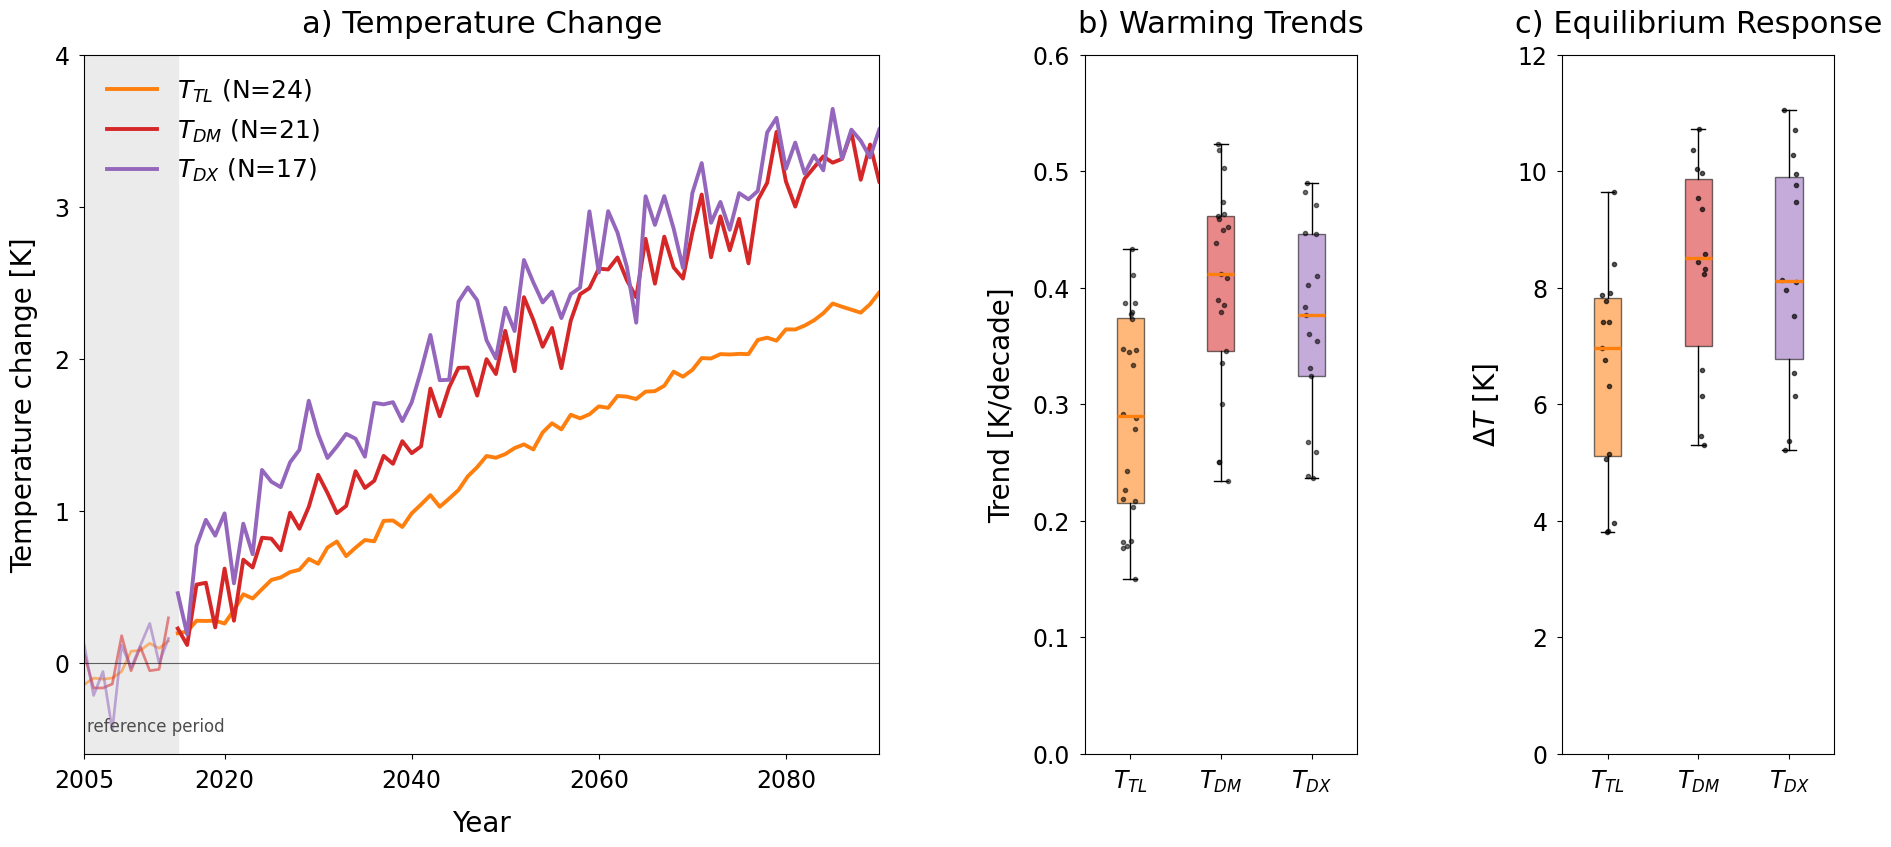

<Figure size 640x480 with 0 Axes>

In [20]:
# ================== Full 3-panel figure: hist(2005–2014)+SSP245 + abrupt/piControl ==================
import numpy as np, scipy.stats as ss
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib import ticker as mticker
from pathlib import Path

# --------------------------------------------------------------------------------
# 0) CONFIG
# --------------------------------------------------------------------------------
# Folder where you copied the concatenated files (*_hist2005-2014+ssp245_*.npy)
CONCAT_DIR = Path("/content/drive/MyDrive/cmip/indices_day_filtered_ssp_hist")

# Optional: where your abrupt/piControl files live (only needed if your load_metric ignores paths)
# EXPTS_DIR = Path("/content/drive/MyDrive/cmip/experiments")

REFERENCE_PERIOD = (2005, 2014)   # all-historical baseline for anomalies
TRENDS_USE_SSP_ONLY = True        # Panel (b): compute trends from 2015 onward
B_MAX = 0.60                      # Panel (b) y-limit
K_FENCE_C = 1.5                   # Tukey fence for panel (c) outlier removal

# Allowed models (no MPI)
ALLOWED = {
    "ACCESS-CM2","ACCESS-ESM1-5","AWI-CM-1-1-MR","CAMS-CSM1-0","CMCC-CM2-SR5","CMCC-ESM2",
    "CNRM-CM6-1","CNRM-CM6-1-HR","CNRM-ESM2-1","CanESM5","EC-Earth3","EC-Earth3-CC",
    "EC-Earth3-Veg","EC-Earth3-Veg-LR","GFDL-CM4","GFDL-ESM4","HadGEM3-GC31-LL","IITM-ESM",
    "INM-CM4-8","INM-CM5-0","IPSL-CM6A-LR","NorESM2-LM","NorESM2-MM","TaiESM1","UKESM1-0-LL"
}

# --------------------------------------------------------------------------------
# 1) LOAD DATA
# --------------------------------------------------------------------------------
# Your loader: must exist in the environment.
# load_metric(exp, kind) -> dict(model -> 1D np.ndarray)
#   exp  in {"ssp245","abrupt-4xCO2","piControl"} (you can ignore "historical")
#   kind in {"TTL","TDM","TDX"}

# A) Concatenated hist(2005–2014)+SSP245 for panels (a) & (b) from CONCAT_DIR
def load_concat_kind(kind):  # kind in {"TTL","TDM","TDX"}
    series, years = {}, {}
    files = sorted(CONCAT_DIR.glob(f"*hist2005-2014+ssp245_{kind}.npy"))
    if not files:
        raise FileNotFoundError(f"No concat files found for {kind} in {CONCAT_DIR}")
    for p in files:
        model = p.name.split(f"_hist2005-2014+ssp245_{kind}.npy")[0]
        if model not in ALLOWED:
            continue
        arr = np.load(p)
        ypath = p.with_name(p.name.replace(f"_{kind}.npy", f"_{kind}_years.npy"))
        yrs = np.load(ypath).astype(int) if ypath.exists() else np.arange(2005, 2005 + arr.size)
        series[model] = arr
        years[model]  = yrs
    return series, years

TTL_s_concat, TTL_years = load_concat_kind("TTL")
TDM_s_concat, TDM_years = load_concat_kind("TDM")
TDX_s_concat, TDX_years = load_concat_kind("TDX")

# keep models present in each metric
mods_TL = sorted(ALLOWED & set(TTL_s_concat))
mods_DM = sorted(ALLOWED & set(TDM_s_concat))
mods_DX = sorted(ALLOWED & set(TDX_s_concat))

# Shared length across metrics
def _min_len(models, store):
    return min(len(store[m]) for m in models) if models else 0

L_panel = min(_min_len(mods_TL, TTL_s_concat),
              _min_len(mods_DM, TDM_s_concat),
              _min_len(mods_DX, TDX_s_concat))
if L_panel == 0:
    raise RuntimeError("Concatenated series exist but lengths don’t overlap; check files.")

# Truncate everything to a common length and construct a common year axis
def _truncate(store, years, L):
    for m in list(store.keys()):
        store[m] = np.asarray(store[m][:L], float)
        years[m] = np.asarray(years[m][:L], int)

_truncate(TTL_s_concat, TTL_years, L_panel)
_truncate(TDM_s_concat, TDM_years, L_panel)
_truncate(TDX_s_concat, TDX_years, L_panel)

years = np.arange(2005, 2005 + L_panel)

# B) abrupt-4xCO2 and piControl dicts for panel (c) using your loader
TTL_a = load_metric("abrupt-4xCO2", "TTL")
TDM_a = load_metric("abrupt-4xCO2", "TDM")
TDX_a = load_metric("abrupt-4xCO2", "TDX")
TTL_p = load_metric("piControl", "TTL")
TDM_p = load_metric("piControl", "TDM")
TDX_p = load_metric("piControl", "TDX")

# --------------------------------------------------------------------------------
# 2) COMPUTE MME ANOMALIES (panel a) & TRENDS (panel b)
# --------------------------------------------------------------------------------
def anom_first(series, yrs, ref_period=REFERENCE_PERIOD):
    s = np.asarray(series, float); y = np.asarray(yrs, int)
    rp = (y >= ref_period[0]) & (y <= ref_period[1])
    base = np.nanmean(s[rp])
    return s - base

def mme_anom_metric(models, store, years_dict, L):
    mats = []
    for m in models:
        s = np.asarray(store[m][:L], float)
        y = np.asarray(years_dict[m][:L], int)
        mats.append(anom_first(s, y))
    return np.nanmean(np.vstack(mats), axis=0) if mats else np.full(L, np.nan)

ttl_mme = mme_anom_metric(mods_TL, TTL_s_concat, TTL_years, L_panel)
tdm_mme = mme_anom_metric(mods_DM, TDM_s_concat, TDM_years, L_panel)
tdx_mme = mme_anom_metric(mods_DX, TDX_s_concat, TDX_years, L_panel)

def slopes_for_metric(models, store, years_dict, L, ssp_only=TRENDS_USE_SSP_ONLY):
    out = []
    for m in models:
        yv = np.asarray(years_dict[m][:L], int)
        sv = np.asarray(store[m][:L], float)  # slope on raw values
        mask = (yv >= 2015) if ssp_only else np.isfinite(sv)
        out.append(ss.linregress(yv[mask], sv[mask]).slope * 10.0 if mask.sum() >= 2 else np.nan)
    return np.array(out, float)

sl_TL = slopes_for_metric(mods_TL, TTL_s_concat, TTL_years, L_panel)
sl_DM = slopes_for_metric(mods_DM, TDM_s_concat, TDM_years, L_panel)
sl_DX = slopes_for_metric(mods_DX, TDX_s_concat, TDX_years, L_panel)

# --------------------------------------------------------------------------------
# 3) EQUILIBRIUM RESPONSE (panel c): abrupt4xCO2 − piControl w/ Tukey filter
# --------------------------------------------------------------------------------
def last_mean(a, n=30):
    a = np.asarray(a)
    n = min(n, a.size)
    return float(np.nanmean(a[-n:])) if n > 0 else np.nan

def tukey_mask(x, k=1.5):
    x = np.asarray(x, float)
    q1, q3 = np.nanpercentile(x, 25), np.nanpercentile(x, 75)
    iqr = q3 - q1
    low, high = q1 - k*iqr, q3 + k*iqr
    return (np.isfinite(x) & (x >= low) & (x <= high))

# models present in all six dictionaries and allowed
ab_common = sorted((set(TTL_a)&set(TDM_a)&set(TDX_a)&set(TTL_p)&set(TDM_p)&set(TDX_p)) & ALLOWED)

resp_TL, resp_DM, resp_DX = [], [], []
for m in ab_common:
    TL = last_mean(TTL_a[m], 30) - float(np.nanmean(TTL_p[m]))
    DM = last_mean(TDM_a[m], 30) - float(np.nanmean(TDM_p[m]))
    DX = last_mean(TDX_a[m], 30) - float(np.nanmean(TDX_p[m]))
    resp_TL.append(TL); resp_DM.append(DM); resp_DX.append(DX)

resp_TL, resp_DM, resp_DX = map(np.asarray, (resp_TL, resp_DM, resp_DX))
mTL = tukey_mask(resp_TL, k=K_FENCE_C)
mDM = tukey_mask(resp_DM, k=K_FENCE_C)
mDX = tukey_mask(resp_DX, k=K_FENCE_C)
TL_filt, DM_filt, DX_filt = resp_TL[mTL], resp_DM[mDM], resp_DX[mDX]

# --------------------------------------------------------------------------------
# 4) PLOTTING
# --------------------------------------------------------------------------------
plt.rcParams.update({
    "font.size": 18, "axes.titlesize": 22, "axes.labelsize": 20,
    "xtick.labelsize": 17, "ytick.labelsize": 17, "legend.fontsize": 18,
    "axes.titlepad": 16, "axes.labelpad": 12
})
LW = 2.8
LW_EARLY = LW * 0.7
ALPHA_EARLY = 0.55
cs = [(255/255,127/255,14/255), (214/255,39/255,40/255), (148/255,103/255,189/255)]

fig = plt.figure(figsize=(20, 9.2))
gs = gridspec.GridSpec(1, 3, width_ratios=[3.8, 1.3, 1.3])
fig.subplots_adjust(left=0.11, right=0.985, top=0.90, bottom=0.14, wspace=0.46)

# (a) Time series (anomalies)
ax = plt.subplot(gs[0])
ax.set_title("a) Temperature Change", pad=16)
ax.axvspan(REFERENCE_PERIOD[0], REFERENCE_PERIOD[1] + 0.999, color="0.92", zorder=0)

mask_early = (years >= REFERENCE_PERIOD[0]) & (years <= REFERENCE_PERIOD[1])
mask_late  = years > REFERENCE_PERIOD[1]
for series, color, label in [
    (ttl_mme, cs[0], rf"$T_{{TL}}$ (N={len(mods_TL)})"),
    (tdm_mme, cs[1], rf"$T_{{DM}}$ (N={len(mods_DM)})"),
    (tdx_mme, cs[2], rf"$T_{{DX}}$ (N={len(mods_DX)})"),
]:
    ax.plot(years[mask_early], series[mask_early], lw=LW_EARLY, alpha=ALPHA_EARLY, color=color)
    ax.plot(years[mask_late],  series[mask_late],  lw=LW,        alpha=1.0,        color=color, label=label)
ax.axhline(0, color='k', lw=0.8, alpha=0.6)
ax.set_xlabel("Year"); ax.set_ylabel("Temperature change [K]")
ax.set_xlim([years[0], min(years[-1], 2090)])
ax.set_xticks([2005, 2020, 2040, 2060, 2080])
ax.set_ylim([-0.6, 4.0]); ax.yaxis.set_major_locator(mticker.MultipleLocator(1.0))
ax.tick_params(pad=7)
ax.text(REFERENCE_PERIOD[0]+0.3, -0.48, "reference period", ha="left", va="bottom",
        fontsize=12, color="0.3")
ax.legend(loc="upper left", ncol=1, frameon=False)

# (b) Warming trends
ax2 = plt.subplot(gs[1])
ax2.set_title("b) Warming Trends" if TRENDS_USE_SSP_ONLY else "b) Warming Trends", pad=16)
bp = ax2.boxplot((sl_TL, sl_DM, sl_DX), patch_artist=True, whis=1)
for box, c in zip(bp['boxes'], cs):
    box.set_facecolor(c); box.set_alpha(0.55)
for med in bp['medians']: med.set_linewidth(2.4)
rng = np.random.default_rng(0)
for i, arr in enumerate((sl_TL, sl_DM, sl_DX), start=1):
    x = np.full(arr.size, i) + rng.uniform(-0.08, 0.08, arr.size)
    ax2.plot(x, arr, ".", ms=6, alpha=0.55, color="k")
ax2.set_ylabel("Trend [K/decade]")
ax2.set_xticks([1, 2, 3]); ax2.set_xticklabels([r"$T_{TL}$", r"$T_{DM}$", r"$T_{DX}$"])
ax2.set_ylim([0.0, B_MAX]); ax2.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
ax2.tick_params(pad=7)

# (c) Equilibrium response (abrupt4×CO2 − piControl; outliers removed)
ax3 = plt.subplot(gs[2])
ax3.set_title("c) Equilibrium Response", pad=16)
bp2 = ax3.boxplot((TL_filt, DM_filt, DX_filt), patch_artist=True, whis=1.5, showfliers=False)
for box, c in zip(bp2['boxes'], cs):
    box.set_facecolor(c); box.set_alpha(0.55)
for med in bp2['medians']: med.set_linewidth(2.4)
for i, arr in enumerate((TL_filt, DM_filt, DX_filt), start=1):
    x = np.full(arr.size, i) + rng.uniform(-0.08, 0.08, arr.size)
    ax3.plot(x, arr, ".", ms=6, alpha=0.65, color="k")
ax3.set_ylabel(r"$\Delta T$ [K]")
ax3.set_xticks([1, 2, 3]); ax3.set_xticklabels([r"$T_{TL}$", r"$T_{DM}$", r"$T_{DX}$"])
ax3.set_ylim([0.0, 12.0]); ax3.yaxis.set_major_locator(mticker.MultipleLocator(2.0))
ax3.tick_params(pad=7)

plt.show()
plt.savefig("fig1_hist-baseline_2005-2014_FULL.png", dpi=600, bbox_inches="tight")
plt.savefig("fig1_hist-baseline_2005-2014_FULL.pdf", bbox_inches="tight")
